# Industrial Defect Prediction

End-to-end analysis of highly imbalanced starter-motor quality data, from process exploration and temporal feature engineering to model comparison and operational evaluation.

## Notebook roadmap

1. Assess data quality and the extreme target imbalance.
2. Explore sensor behavior and class separability.
3. Construct process-aware and past-only temporal features.
4. Compare linear, tree-based, anomaly-detection, and neural models.
5. Evaluate ensembles through ranking metrics and operational false alarms.
6. Check robustness across time windows and generate challenge predictions.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
import math
from scipy.stats import ks_2samp
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Use Device: {device}")

# Settings
pd.set_option("display.max_columns", None)

Use Device: mps


# 1. Data preparation

## 1.1 Dataset Assessment

We perform an inner join between the sensor inputs and the production outputs to create a unified, labeled dataset. This ensures that every sensor reading is correctly associated with its production outcome (OK/KO).

In [49]:
# Load datasets
inputs_df = pd.read_csv("data/traininginputs.csv")
output_df = pd.read_csv("data/trainingoutput.csv")
test_df = pd.read_csv("data/testinputs.csv")

# Identify target column and ID column
target_col = output_df.columns[-1] 
id_col = inputs_df.columns[0]      

# Perform inner join
df = inputs_df.merge(output_df, on=id_col, how="inner")

print("--- Dataset Dimensions ---")
print(f"Merged Dataset Shape: {df.shape}")
print(f" - Samples (N): {df.shape[0]}")
print(f" - Features + Target (D): {df.shape[1]}")

print("\n--- Feature Types ---")
print(df.dtypes.value_counts())

--- Dataset Dimensions ---
Merged Dataset Shape: (34515, 15)
 - Samples (N): 34515
 - Features + Target (D): 15

--- Feature Types ---
float64    13
object      1
int64       1
Name: count, dtype: int64


We analyze the distribution of the target variable to determine the ratio between 'OK' (0) and 'KO' (1) samples. Identifying this balance is essential for selecting appropriate evaluation metrics and handling strategies.

In [50]:
# Analyzing the balance between the 'OK' (0) and 'KO' (1) classes.
counts = df[target_col].value_counts()
percentage = df[target_col].value_counts(normalize=True) * 100

print(f"Target Column: '{target_col}'")
print("\nAbsolute Counts:")
print(counts)

print("\nRelative Distribution (%):")
print(percentage.round(2))

Target Column: 'Binar OP130_Resultat_Global_v'

Absolute Counts:
Binar OP130_Resultat_Global_v
0    34210
1      305
Name: count, dtype: int64

Relative Distribution (%):
Binar OP130_Resultat_Global_v
0    99.12
1     0.88
Name: proportion, dtype: float64


We compute descriptive statistics (mean, std, min, max) for the continuous features to assess value ranges and data completeness. This helps to identify physical scale disparities and potential missing values across the sensor set.

In [51]:
feature_stats = df.drop(columns=['PROC_TRACEINFO', target_col]).describe().transpose()

print("--- Descriptive Statistics of Features ---")
display(feature_stats)

--- Descriptive Statistics of Features ---


,count,mean,std,min,25%,50%,75%,max
OP070_V_1_angle_value,34515.0,159.906922,15.662650,101.80,148.70,158.00,169.30,198.30
OP090_SnapRingPeakForce_value,34515.0,156.915055,11.271492,0.00,149.21,156.18,164.38,196.92
OP070_V_2_angle_value,34515.0,159.618236,15.091490,82.00,149.40,158.70,168.90,198.10
OP120_Rodage_I_mesure_value,34515.0,113.350222,3.528522,99.99,111.04,113.16,115.38,177.95
OP090_SnapRingFinalStroke_value,34515.0,11.970190,0.169873,0.00,11.85,12.04,12.08,12.19
OP110_Vissage_M8_torque_value,34515.0,12.256785,0.065319,12.03,12.21,12.26,12.30,12.50
OP100_Capuchon_insertion_mesure,15888.0,0.388173,0.024425,0.24,0.38,0.39,0.41,0.42
OP120_Rodage_U_mesure_value,34515.0,11.971027,0.003050,11.97,11.97,11.97,11.97,11.99
OP070_V_1_torque_value,34515.0,6.548403,0.097602,5.67,6.41,6.61,6.62,6.67
OP090_StartLinePeakForce_value,34515.0,23.630152,2.546341,0.00,22.28,23.88,25.29,43.41


## 1.2 Data Quality
We assess data integrity by checking for redundant observations and missing sensor readings. Identifying these issues early is crucial to prevent data leakage and to determine which features require imputation or removal.

In [52]:
print("--- Duplicate Analysis ---")
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

--- Duplicate Analysis ---
Total Duplicate Rows: 0


In [53]:
print("--- Missing Values Analysis ---")
missing_values = df.isnull().sum()
missing_features = missing_values[missing_values > 0]

if missing_features.empty:
    print("No missing values found.")
else:
    for feature, count in missing_features.items():
        print(f"{feature}: {count}")

--- Missing Values Analysis ---
OP100_Capuchon_insertion_mesure: 18627


## 1.3 Data Cleaning & Imputation


Based on the assessment, we identified a critical pattern in the missing values of OP100. Instead of immediate deletion, we first quantify the impact of these missing values on the process outcome.

In [54]:
# --- Impact Analysis (Observation for Report) ---
missing_col = "OP100_Capuchon_insertion_mesure"
ko_rate_missing = df[df[missing_col].isna()][target_col].mean()
ko_rate_present = df[df[missing_col].notna()][target_col].mean()

print(f"\n--- Observation: Process Influence ---")
print(f"KO Rate when {missing_col} is missing: {ko_rate_missing:.4f}")
print(f"KO Rate when {missing_col} is present: {ko_rate_present:.4f}")


--- Observation: Process Influence ---
KO Rate when OP100_Capuchon_insertion_mesure is missing: 0.0059
KO Rate when OP100_Capuchon_insertion_mesure is present: 0.0123


To handle the missing values identified in the previous analysis, we define a reusable function apply_imputation using the Median strategy.

**Timing Consideration:** 
We explicitly postpone the application of this function.
* Reason 1 (Validation): To prevent Data Leakage, imputation statistics must be calculated solely on the training set after splitting.
* Reason 2 (Visualization): The upcoming EDA section requires access to the raw data (including gaps) to analyze the authentic distributions.

In [55]:
def apply_imputation(train, val, test, strategy="median"):
    imputer = SimpleImputer(strategy=strategy)
    numeric_cols = train.select_dtypes(include=np.number).columns
    
    train_imp = pd.DataFrame(imputer.fit_transform(train[numeric_cols]), columns=numeric_cols, index=train.index)
    val_imp = pd.DataFrame(imputer.transform(val[numeric_cols]), columns=numeric_cols, index=val.index)
    test_imp = pd.DataFrame(imputer.transform(test[numeric_cols]), columns=numeric_cols, index=test.index)
    
    return train_imp, val_imp, test_imp

## 1.4 Outlier Detection

We analyzed the distribution of continuous sensor features using the IQR method. As shown in the table above, the outlier rate varies significantly across features. While the majority exhibits stable distributions with outlier rates below $3\%$, specific features show high deviations (e.g., OP120_Rodage_U_mesure_value with $>10\%$ and OP110_Vissage_M8_angle_value with $>5\%$).

In [56]:
numerical_cols = df.drop(columns=[id_col, target_col]).select_dtypes(include=['float64', 'int64']).columns

outlier_stats = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    perc_outliers = (n_outliers / len(df)) * 100
    
    outlier_stats.append({
        "Feature": col,
        "IQR": round(IQR, 3),
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Outliers_Count": n_outliers,
        "Outliers_%": round(perc_outliers, 2)
    })

outlier_df = pd.DataFrame(outlier_stats).sort_values("Outliers_%", ascending=False)

print("--- Outlier Analysis Table ---")
display(outlier_df)

--- Outlier Analysis Table ---


,Feature,IQR,Lower_Bound,Upper_Bound,Outliers_Count,Outliers_%
7,OP120_Rodage_U_mesure_value,0.00,11.97,11.97,3532,10.23
10,OP110_Vissage_M8_angle_value,6.70,3.45,30.25,1898,5.50
11,OP090_SnapRingMidPointForce_val,7.92,82.43,114.11,1490,4.32
9,OP090_StartLinePeakForce_value,3.01,17.77,29.80,988,2.86
3,OP120_Rodage_I_mesure_value,4.34,104.53,121.89,595,1.72
6,OP100_Capuchon_insertion_mesure,0.03,0.34,0.45,592,1.72
5,OP110_Vissage_M8_torque_value,0.09,12.08,12.44,236,0.68
2,OP070_V_2_angle_value,19.50,120.15,198.15,80,0.23
1,OP090_SnapRingPeakForce_value,15.17,126.46,187.14,63,0.18
0,OP070_V_1_angle_value,20.60,117.80,200.20,48,0.14


In [57]:
def apply_clipping(train, val, test, lower_q=0.001, upper_q=0.999):
    lower = train.quantile(lower_q)
    upper = train.quantile(upper_q)
    
    train_clip = train.clip(lower=lower, upper=upper, axis=1)
    val_clip = val.clip(lower=lower, upper=upper, axis=1)
    test_clip = test.clip(lower=lower, upper=upper, axis=1)
    
    return train_clip, val_clip, test_clip

## 1.5 Feature Scaling
As observed in the data assessment, the sensor features span vastly different physical ranges (e.g., Torques $\approx 10$ Nm vs. Angles $\approx 200^{\circ}$). To ensure unbiased model performance and convergence, scaling is required to normalize these values.

In [58]:
def apply_scaling(train, val, test):
    scaler = RobustScaler()
    
    train_sc = pd.DataFrame(scaler.fit_transform(train), columns=train.columns, index=train.index)
    val_sc = pd.DataFrame(scaler.transform(val), columns=val.columns, index=val.index)
    test_sc = pd.DataFrame(scaler.transform(test), columns=test.columns, index=test.index)
    
    return train_sc, val_sc, test_sc

# 2. Exploratory analysis

## 2.1 Correlation Matrix

We begin by examining the linear relationships between all numerical features and the target variable. We calculate the Pearson correlation coefficient, which ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation).


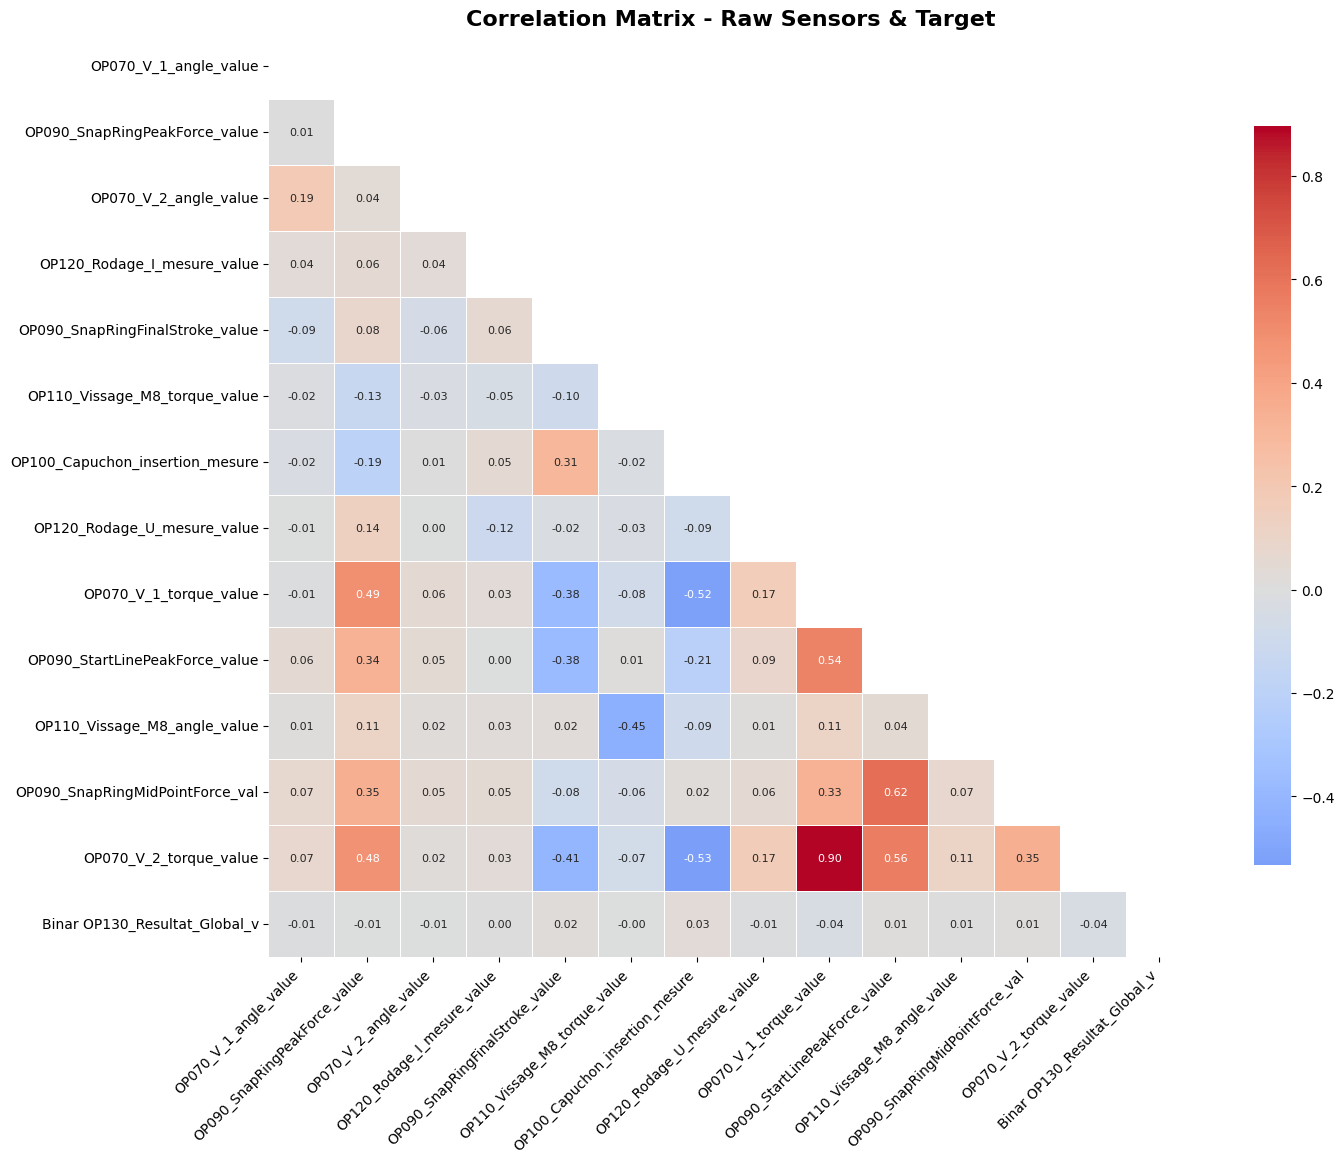

In [59]:
plot_corr_df = df.drop(columns=[id_col]).select_dtypes(include=[np.number])
plt.figure(figsize=(16, 12))
corr = plot_corr_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask=mask, 
    cmap="coolwarm", 
    center=0, 
    annot=True, 
    fmt=".2f", 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix - Raw Sensors & Target", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.show()

## 2.2 Principal Component Analysis
We perform Principal Component Analysis (PCA) in 2D and 3D to investigate if a linear combination of all sensor features can separate the classes, going beyond individual correlations. Prior to projection, we apply the RobustScaler to mitigate the impact of outliers.

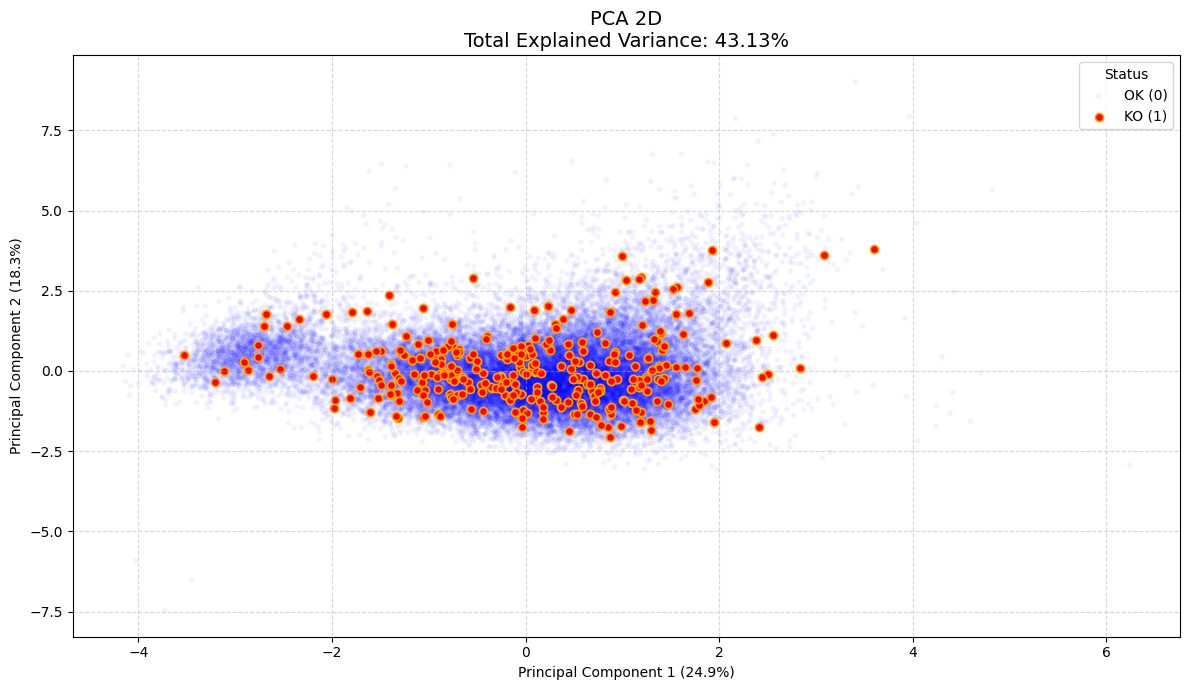

In [60]:
viz_features = df.drop(columns=[id_col, target_col]).select_dtypes(include=[np.number])
viz_imputer = SimpleImputer(strategy="median")
viz_imputed = viz_imputer.fit_transform(viz_features)

viz_scaled = RobustScaler().fit_transform(viz_imputed)
pca = PCA(n_components=2)
X_pca_res = pca.fit_transform(viz_scaled)

plt.figure(figsize=(12, 7))

mask_ok = df[target_col] == 0
mask_ko = df[target_col] == 1

plt.scatter(
    X_pca_res[mask_ok, 0], 
    X_pca_res[mask_ok, 1], 
    c='blue', 
    label='OK (0)',
    alpha=0.05, 
    s=15, 
    marker='o',
    edgecolors='none'
)

plt.scatter(
    X_pca_res[mask_ko, 0], 
    X_pca_res[mask_ko, 1], 
    c='red', 
    label='KO (1)',
    alpha=1.0, 
    s=35, 
    marker='o',
    edgecolors='orange',
    linewidths=1.2
)

explained_var = np.sum(pca.explained_variance_ratio_) * 100
plt.title(f"PCA 2D\nTotal Explained Variance: {explained_var:.2f}%", fontsize=14)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(title='Status', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [61]:
import plotly.express as px

viz_features = df.drop(columns=[id_col, target_col]).select_dtypes(include=[np.number])
viz_imputer = SimpleImputer(strategy="median")
viz_imputed = viz_imputer.fit_transform(viz_features)

viz_scaled = RobustScaler().fit_transform(viz_imputed)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(viz_scaled)

df_pca_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca_3d['Label'] = df[target_col].values
df_pca_3d['Status'] = df_pca_3d['Label'].map({0: 'OK', 1: 'KO'})

total_var = np.sum(pca_3d.explained_variance_ratio_) * 100

fig = px.scatter_3d(
    df_pca_3d, 
    x='PC1', y='PC2', z='PC3',
    color='Status',
    color_discrete_map={'OK': 'blue', 'KO': 'red'},
    title=f"PCA 3D Visualization (Total Variance: {total_var:.2f}%)",
    opacity=0.6 
)

fig.update_traces(selector=dict(name='OK'), marker=dict(size=3, opacity=0.1))
fig.update_traces(selector=dict(name='KO'), marker=dict(size=5, opacity=1.0, line=dict(width=2, color='orange')))

fig.update_layout(margin=dict(l=0, r=0, b=0, t=30))
fig.show()

## 2.3 t-SNE (Manifold Learning)
We apply t-SNE dimensionality reduction to a stratified sample of the high-dimensional sensor data to uncover complex, non-linear structures and visually assess whether defective parts form distinguishable clusters separate from the functional majority.

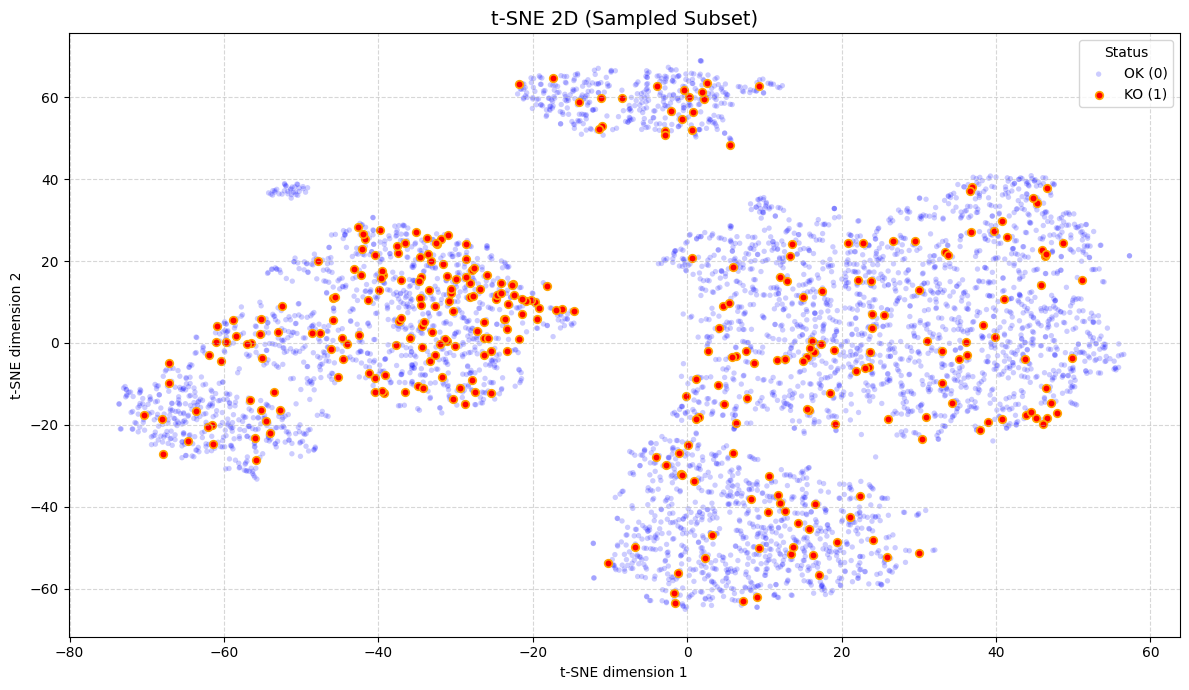

In [62]:
df_ko = df[df[target_col] == 1]
df_ok = df[df[target_col] == 0]

df_sample = pd.concat([
    df_ko,
    df_ok.sample(n=min(4500, len(df_ok)), random_state=42)
])

X_tsne_features = df_sample.drop(columns=[id_col, target_col]).select_dtypes(include=[np.number])
y_tsne_labels = df_sample[target_col]

tsne_imputer = SimpleImputer(strategy="median")
X_tsne_imputed = tsne_imputer.fit_transform(X_tsne_features)
X_tsne_scaled = StandardScaler().fit_transform(X_tsne_imputed)

tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    random_state=42, 
    init='pca', 
    learning_rate='auto',
    n_jobs=-1
)
X_tsne_res = tsne.fit_transform(X_tsne_scaled)

plt.figure(figsize=(12, 7))

mask_ok = y_tsne_labels == 0
mask_ko = y_tsne_labels == 1

plt.scatter(
    X_tsne_res[mask_ok, 0], 
    X_tsne_res[mask_ok, 1], 
    c='blue', 
    label='OK (0)',
    alpha=0.2, 
    s=15, 
    marker='o',
    edgecolors='none'
)

plt.scatter(
    X_tsne_res[mask_ko, 0], 
    X_tsne_res[mask_ko, 1], 
    c='red', 
    label='KO (1)',
    alpha=1.0, 
    s=30, 
    marker='o',
    edgecolors='orange',
    linewidths=1.2
)

plt.title("t-SNE 2D (Sampled Subset)", fontsize=14)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(title='Status', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

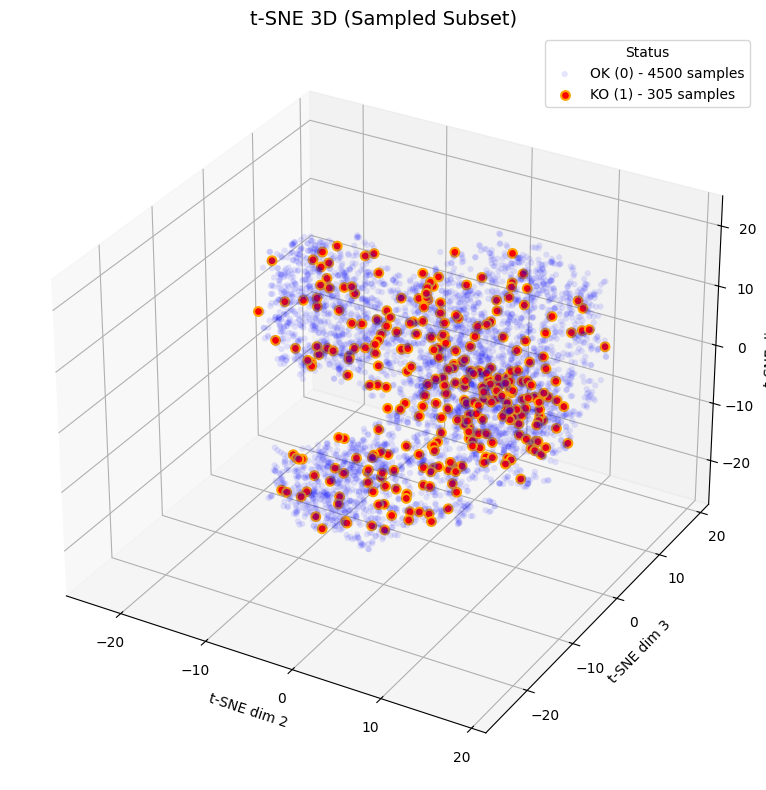

In [63]:
df_ko = df[df[target_col] == 1]
df_ok = df[df[target_col] == 0]

df_sample = pd.concat([
    df_ko,
    df_ok.sample(n=min(4500, len(df_ok)), random_state=42)
])

X_tsne_features = df_sample.drop(columns=[id_col, target_col]).select_dtypes(include=[np.number])
y_tsne_labels = df_sample[target_col]

tsne_imputer = SimpleImputer(strategy="median")
X_tsne_imputed = tsne_imputer.fit_transform(X_tsne_features)
X_tsne_scaled = StandardScaler().fit_transform(X_tsne_imputed)

tsne = TSNE(
    n_components=3, 
    perplexity=30, 
    random_state=42, 
    init='pca', 
    learning_rate='auto',
    n_jobs=-1
)
X_tsne_res = tsne.fit_transform(X_tsne_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

mask_ok = y_tsne_labels == 0
mask_ko = y_tsne_labels == 1

ax.scatter(
    X_tsne_res[mask_ok, 1], 
    X_tsne_res[mask_ok, 2], 
    X_tsne_res[mask_ok, 0],
    c='blue', 
    label='OK (0) - 4500 samples',
    alpha=0.1, 
    s=20, 
    marker='o',
    edgecolors='none'
)

ax.scatter(
    X_tsne_res[mask_ko, 1], 
    X_tsne_res[mask_ko, 2], 
    X_tsne_res[mask_ko, 0],
    c='red', 
    label='KO (1) - 305 samples',
    alpha=1.0, 
    s=40, 
    marker='o',
    edgecolors='orange',
    linewidths=1.5
)

ax.set_title("t-SNE 3D (Sampled Subset)", fontsize=14)
ax.set_xlabel("t-SNE dim 2")
ax.set_ylabel("t-SNE dim 3")
ax.set_zlabel("t-SNE dim 1")

ax.legend(title='Status', loc='upper right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2.4 Boxplot Distribution Analysis
Comparing the distributions of numerical features between the two target groups (0 = OK, 1 = KO) using the KS statistic and visualizing them with boxplots showing the mean and median.

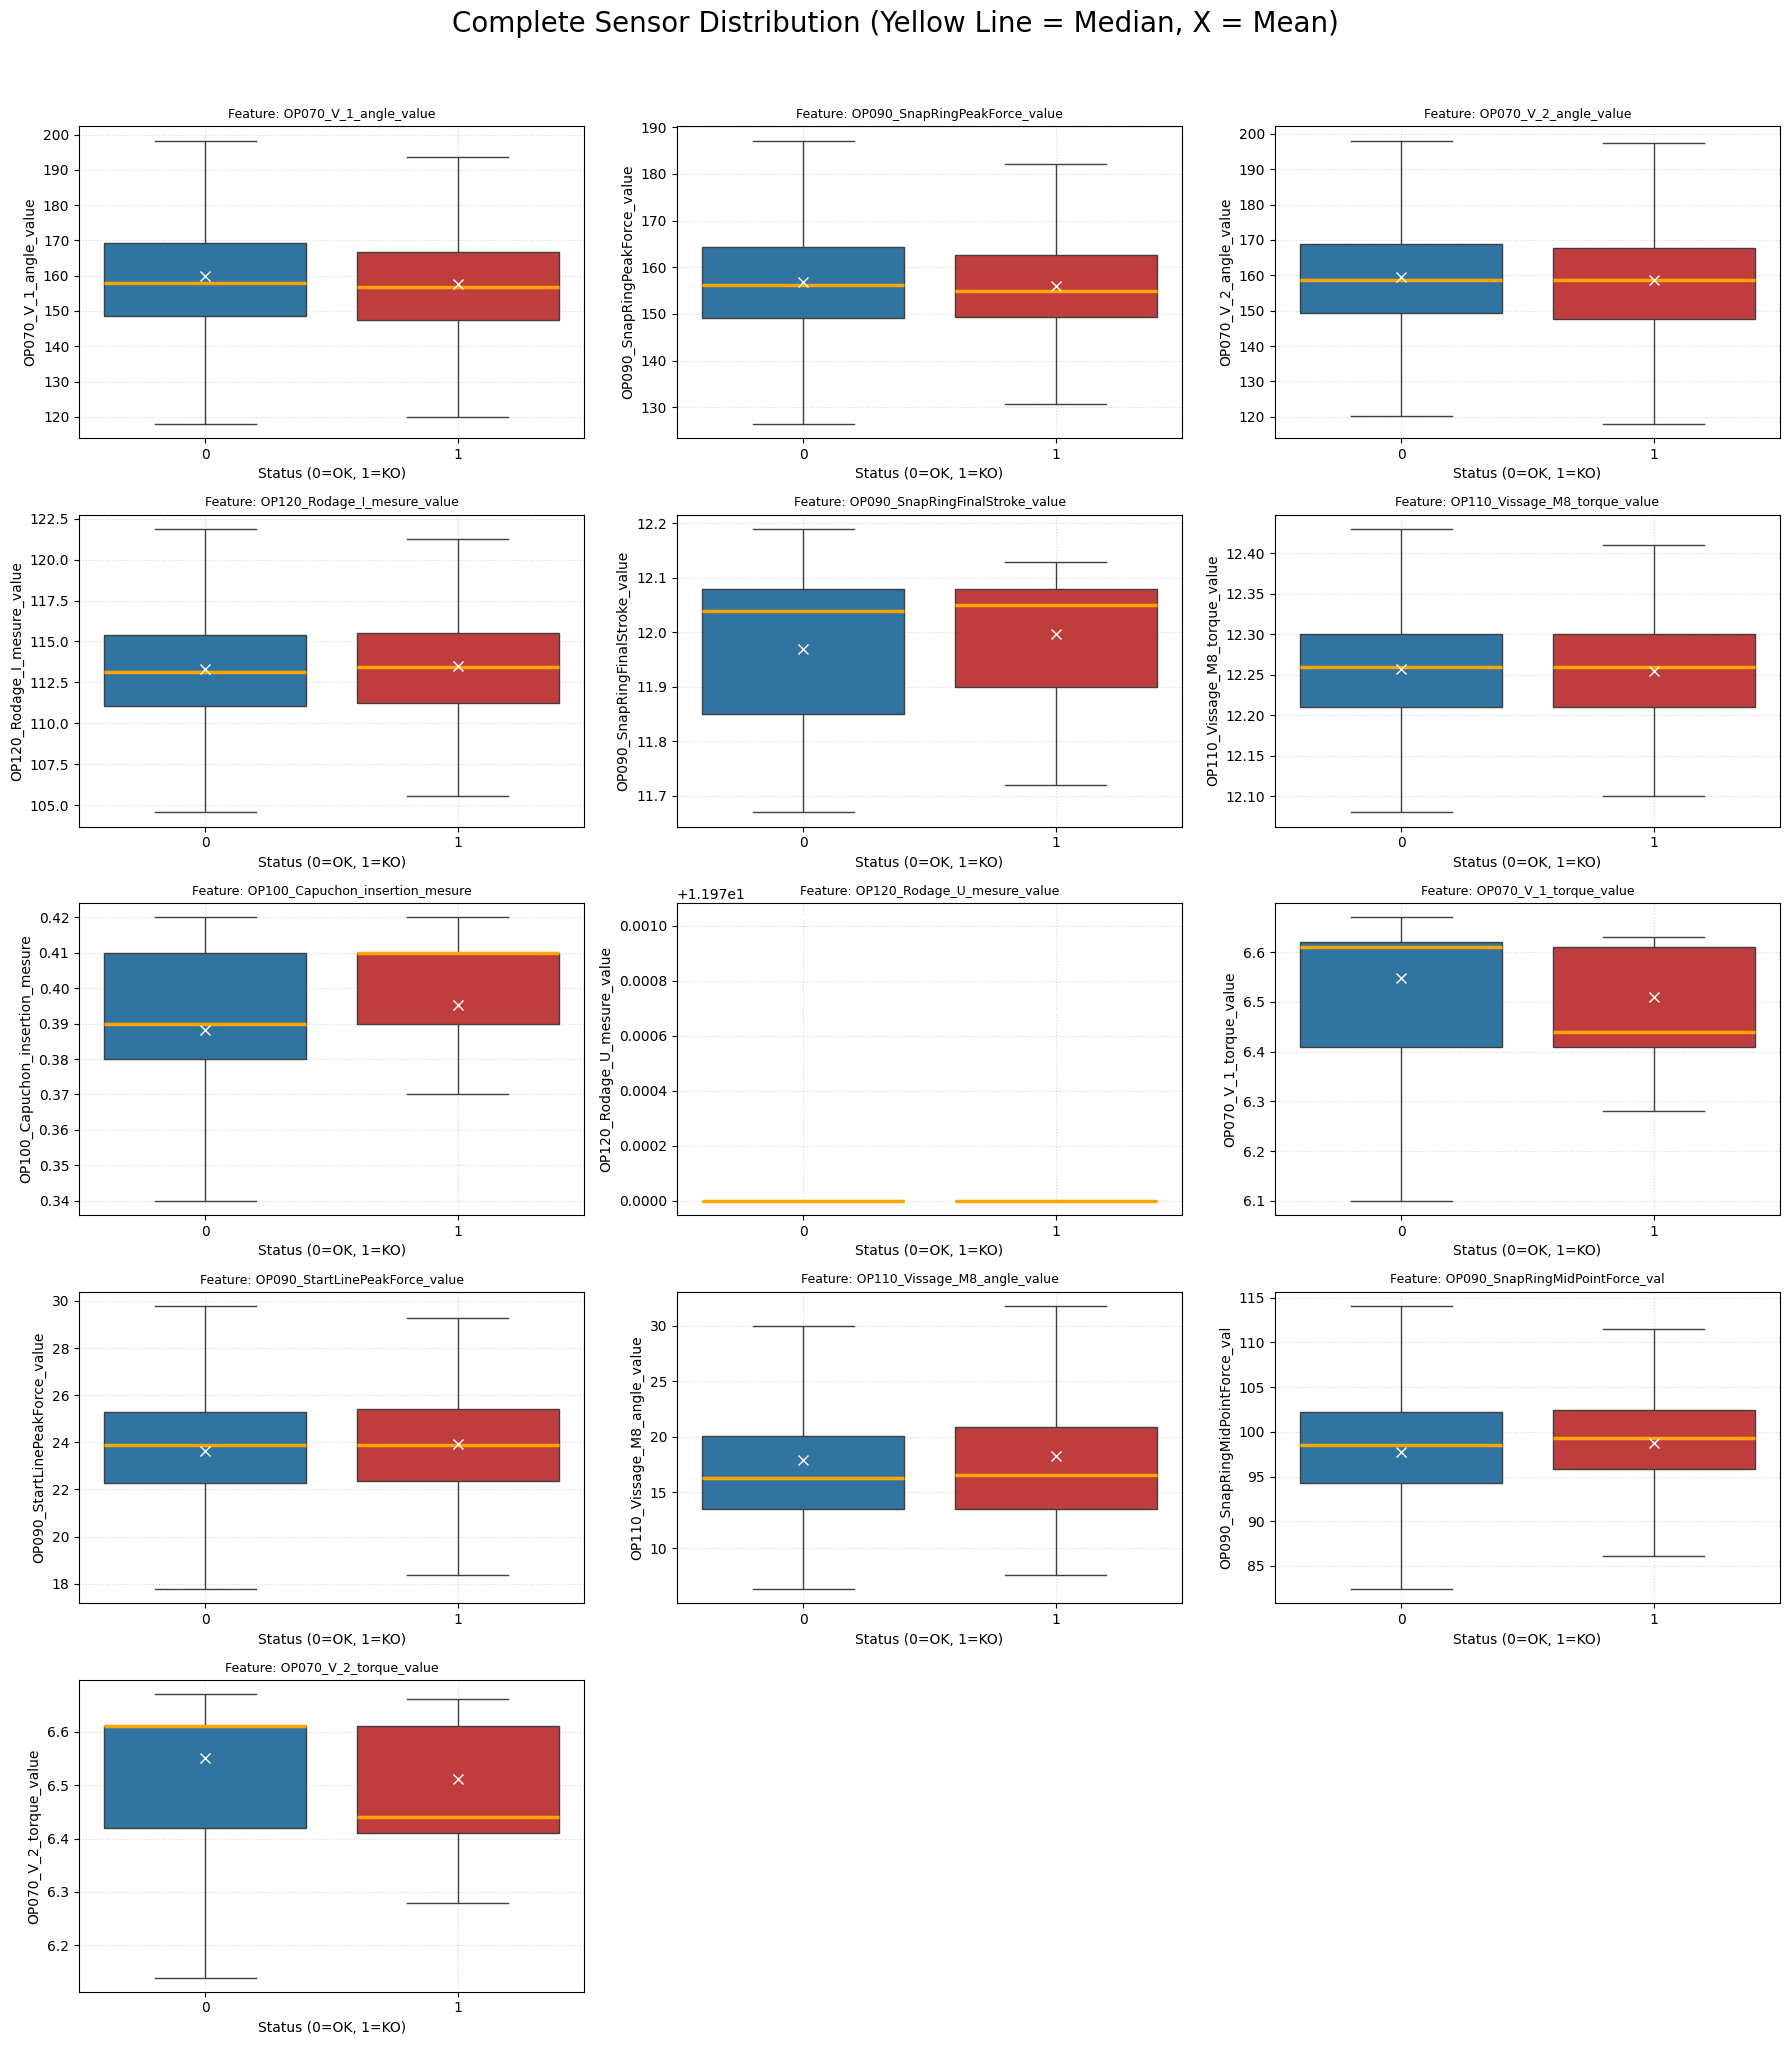

In [64]:
features = df.drop(columns=[id_col, target_col]).select_dtypes(include=[np.number]).columns

ranking = []
for col in features:
    v_ok = df[df[target_col] == 0][col].dropna()
    v_ko = df[df[target_col] == 1][col].dropna()

    stat, _ = ks_2samp(v_ok, v_ko)
    ranking.append({"Feature": col, "KS_Statistic": stat})

df_rank = pd.DataFrame(ranking).sort_values("KS_Statistic", ascending=False)
safe_palette = {0: "tab:blue", 1: "tab:red", "0": "tab:blue", "1": "tab:red"}

n_cols = 3
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(
        x=target_col, y=col, hue=target_col, data=df, ax=axes[i],
        palette=safe_palette, showfliers=False, legend=False,
        showmeans=True,
        meanprops={"marker":"x", "markeredgecolor":"white", "markersize":"7"},
        medianprops={"linewidth": 2.5, "color": "orange"} #
    )
    axes[i].set_title(f"Feature: {col}", fontsize=9)
    axes[i].set_xlabel("Status (0=OK, 1=KO)")
    axes[i].grid(True, linestyle=':', alpha=0.5)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Complete Sensor Distribution (Yellow Line = Median, X = Mean)", fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

Focusing on the top 4 features with the highest KS statistic, visualizing their distributions by target group using boxplots, and highlighting the mean, median, and the KS difference for each feature.

Top 4 Visualization: ['OP100_Capuchon_insertion_mesure', 'OP070_V_2_torque_value', 'OP070_V_1_torque_value', 'OP090_SnapRingFinalStroke_value']


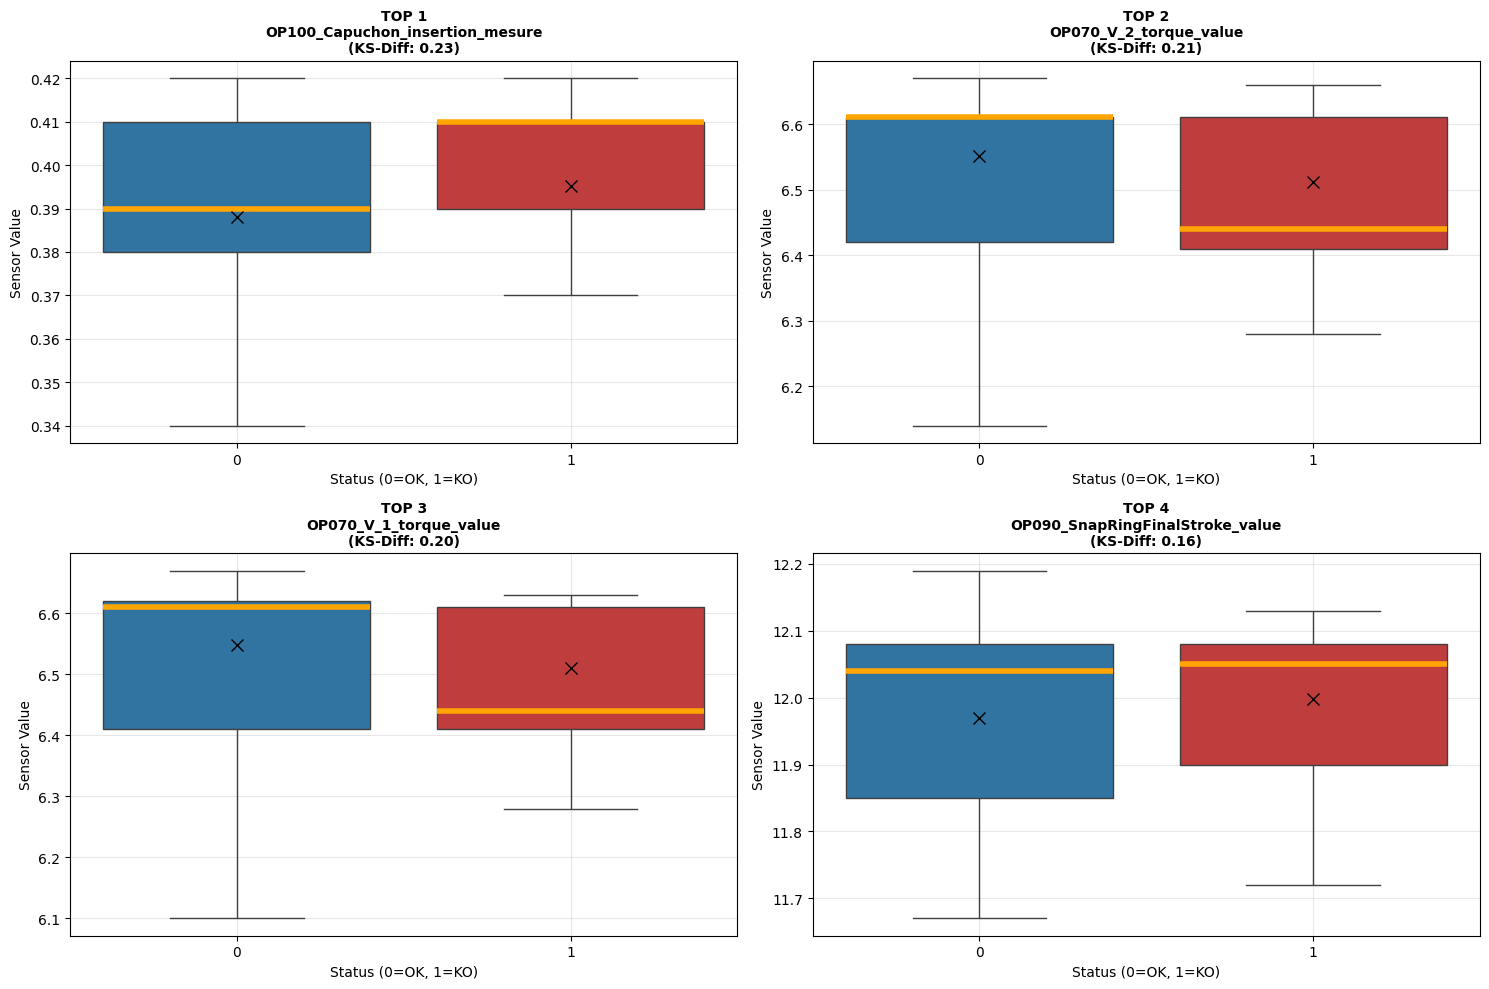

In [65]:
top_features = df_rank["Feature"].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

print(f"Top 4 Visualization: {top_features}")
for i, col in enumerate(top_features):
    sns.boxplot(
        x=target_col, y=col, hue=target_col, data=df, ax=axes[i],
        palette=safe_palette, showfliers=False, legend=False,
        showmeans=True,
        meanprops={"marker":"x", "markeredgecolor":"black", "markersize":"8"},
        medianprops={"linewidth": 4, "color": "orange"}
    )
    
    ks_score = df_rank.iloc[i]['KS_Statistic']
    axes[i].set_title(f"TOP {i+1}\n{col}\n(KS-Diff: {ks_score:.2f})", fontsize=10, fontweight='bold')
    axes[i].set_ylabel("Sensor Value")
    axes[i].set_xlabel("Status (0=OK, 1=KO)")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Feature engineering

## 3.1 Temporal Decomposition 
Extracts date and sequence information from the process trace ID, converts it into separate year, month, and day features, and sorts the dataset by the production sequence index for temporal analysis.

In [66]:
def extract_and_sort_time(df, id_col="PROC_TRACEINFO"):
    df_temp = df.copy()
    
    splits = df_temp[id_col].str.split("-", expand=True)
    df_temp["prod_date_str"] = splits[3]
    df_temp["prod_index"] = splits[4].astype(int)
    
    df_temp["prod_year"] = df_temp["prod_date_str"].str.slice(0, 2).astype(int) + 2000
    df_temp["prod_month"] = df_temp["prod_date_str"].str.slice(2, 4).astype(int)
    df_temp["prod_day"] = df_temp["prod_date_str"].str.slice(4, 6).astype(int)
    
    df_temp = df_temp.sort_values("prod_index").reset_index(drop=True)
    df_temp.drop(columns=["prod_date_str"], inplace=True)
    
    return df_temp

df_sorted = extract_and_sort_time(df)

## 3.2 Domain Feature Extraction
Generates derived features based on domain knowledge, such as missing flags, differences, ratios, energy, and power calculations, to capture meaningful relationships between sensor measurements and operational characteristics.

In [67]:
def add_domain_features(df):
    df_eng = df.copy()

    if "OP100_Capuchon_insertion_mesure" in df_eng.columns:
        df_eng["OP100_missing"] = df_eng["OP100_Capuchon_insertion_mesure"].isna().astype(int)

    if all(c in df_eng.columns for c in ["OP070_V_1_angle_value", "OP070_V_2_angle_value"]):
        df_eng["OP070_angle_diff"] = (df_eng["OP070_V_1_angle_value"] - df_eng["OP070_V_2_angle_value"]).abs()

    if all(c in df_eng.columns for c in ["OP070_V_1_torque_value", "OP070_V_2_torque_value"]):
        df_eng["OP070_torque_diff"] = (df_eng["OP070_V_1_torque_value"] - df_eng["OP070_V_2_torque_value"]).abs()

    if all(c in df_eng.columns for c in ["OP110_Vissage_M8_angle_value", "OP110_Vissage_M8_torque_value"]):
        df_eng["OP110_stiffness_inv"] = df_eng["OP110_Vissage_M8_angle_value"] / (df_eng["OP110_Vissage_M8_torque_value"] + 1e-6)

    if all(c in df_eng.columns for c in ["OP070_V_1_torque_value", "OP070_V_1_angle_value"]):
        df_eng["OP070_V_1_energy"] = df_eng["OP070_V_1_torque_value"] * df_eng["OP070_V_1_angle_value"]
        
    if all(c in df_eng.columns for c in ["OP070_V_2_torque_value", "OP070_V_2_angle_value"]):
        df_eng["OP070_V_2_energy"] = df_eng["OP070_V_2_torque_value"] * df_eng["OP070_V_2_angle_value"]

    if all(c in df_eng.columns for c in ["OP110_Vissage_M8_torque_value", "OP110_Vissage_M8_angle_value"]):
        df_eng["OP110_energy"] = df_eng["OP110_Vissage_M8_torque_value"] * df_eng["OP110_Vissage_M8_angle_value"]

    if all(c in df_eng.columns for c in ["OP120_Rodage_I_mesure_value", "OP120_Rodage_U_mesure_value"]):
        df_eng["OP120_power"] = df_eng["OP120_Rodage_I_mesure_value"] * df_eng["OP120_Rodage_U_mesure_value"]

    if all(c in df_eng.columns for c in ["OP090_SnapRingPeakForce_value", "OP090_SnapRingMidPointForce_val", "OP090_StartLinePeakForce_value"]):
        rise_1 = df_eng["OP090_SnapRingMidPointForce_val"] - df_eng["OP090_StartLinePeakForce_value"]
        rise_2 = df_eng["OP090_SnapRingPeakForce_value"] - df_eng["OP090_SnapRingMidPointForce_val"]
        df_eng["OP090_force_profile"] = rise_2 / (rise_1 + 1e-6)

    return df_eng

df_domain = add_domain_features(df_sorted)

## 3.3 Statistical Rolling Features
This step adds advanced temporal features by computing lag values, first-order differences (deltas), and rolling z-scores for key sensor measurements, capturing short-term trends, shifts, and anomalies over a sliding production window.

In [68]:
def add_advanced_temporal_features(df, window=50):
    df_eng = df.copy()
    
    if "prod_index" in df_eng.columns:
        df_eng = df_eng.sort_values("prod_index")

    
    # --- LAG FEATURES & ROLLING ---
    sensor_cols = [
        "OP070_V_1_angle_value", 
        "OP070_V_1_torque_value",
        "OP090_SnapRingPeakForce_value", 
        "OP090_StartLinePeakForce_value",
        "OP090_SnapRingFinalStroke_value",
        "OP110_Vissage_M8_angle_value", 
        "OP110_Vissage_M8_torque_value",         
        "OP120_Rodage_I_mesure_value"
    ]
    
    cols_to_process = [c for c in sensor_cols if c in df_eng.columns]
    
    for col in cols_to_process:
        # A. LAGS
        df_eng[f"{col}_lag1"] = df_eng[col].shift(1)
        
        # B. DELTA
        df_eng[f"{col}_delta1"] = df_eng[col] - df_eng[col].shift(1)
        
        # C. ROLLING Z-SCORE
        roll_mean = df_eng[col].shift(1).rolling(window=window, min_periods=window//2).mean()
        roll_std = df_eng[col].shift(1).rolling(window=window, min_periods=window//2).std()
        
        df_eng[f"{col}_Z50"] = (df_eng[col] - roll_mean) / (roll_std + 1e-6)
        
    return df_eng

df_full_features = add_advanced_temporal_features(df_domain)

## 3.4 Time-Based Train/Validation/Test Split
Performs a time-based split of the dataset by sorting on the production index and dividing it into training and validation sets, preserving the temporal order to avoid future data leakage.

In [69]:
def perform_time_split(df, target_col, train_ratio=0.7, val_ratio=0.15):
    df_sorted = df.sort_values("prod_index")
    n = len(df_sorted)
    
    idx_train = int(n * train_ratio)
    idx_val = int(n * (train_ratio + val_ratio))
    
    train = df_sorted.iloc[:idx_train].copy()
    val = df_sorted.iloc[idx_train:idx_val].copy()
    test = df_sorted.iloc[idx_val:].copy()
    
    print("--- Split Statistics ---")
    for name, data in zip(['Train', 'Val', 'Test'], [train, val, test]):
        total = len(data)
        ko_count = data[target_col].sum()
        ratio = (ko_count / total) * 100 if total > 0 else 0
        print(f"{name}: {total} samples | {ko_count} KO | {ratio:.2f}%")
        
    return train, val, test

target_col = "Binar OP130_Resultat_Global_v"
train_df, val_df, test_df = perform_time_split(df_full_features, target_col)

--- Split Statistics ---
Train: 24160 samples | 208 KO | 0.86%
Val: 5177 samples | 55 KO | 1.06%
Test: 5178 samples | 42 KO | 0.81%


## 3.5 Dataset Creation & Variations

Multiple model-ready views are created: raw, scaled, engineered, temporal, reduced, and PCA-transformed features. Each view is fitted on the training period and aligned with validation and test periods.

In [70]:
y_train = train_df[target_col]
y_val = val_df[target_col]
y_test = test_df[target_col]

id_cols = ["PROC_TRACEINFO", "product_ref", "prod_date_str", "prod_timestamp", "prod_index", "index_diff"] 
drop_cols = id_cols + [target_col]

eng_keywords = [
    "_Z50", "_diff", "_ratio", "_missing", "_lag", "_delta", 
    "power", "energy", "stiffness", "profile", "inv",
    "_mean", "_std", "_min", "_max", "_median", "_var", "_rolling"
]

all_cols = [c for c in train_df.columns if c not in drop_cols]

raw_cols = [c for c in all_cols if not any(k in c for k in eng_keywords) and c not in ["prod_year", "prod_month", "prod_day"]]
time_cols = ["prod_year", "prod_month", "prod_day"]

X_train_full_clean = train_df[all_cols].loc[:, train_df[all_cols].nunique() > 1]
X_val_full_clean = val_df[all_cols].loc[:, train_df[all_cols].nunique() > 1]
X_test_full_clean = test_df[all_cols].loc[:, train_df[all_cols].nunique() > 1]


# 1. BASELINE
X_train_baseline, X_val_baseline, X_test_baseline = apply_imputation(train_df[raw_cols], val_df[raw_cols], test_df[raw_cols])

# 2. RAW SCALED
X_train_temp, X_val_temp, X_test_temp = apply_imputation(train_df[raw_cols], val_df[raw_cols], test_df[raw_cols])
X_train_temp, X_val_temp, X_test_temp = apply_clipping(X_train_temp, X_val_temp, X_test_temp)
X_train_raw_scaled, X_val_raw_scaled, X_test_raw_scaled = apply_scaling(X_train_temp, X_val_temp, X_test_temp)

# 3. ENGINEERED (Lag + Physik + Rolling)
X_train_temp, X_val_temp, X_test_temp = apply_imputation(X_train_full_clean, X_val_full_clean, X_test_full_clean, strategy="median")
X_train_temp, X_val_temp, X_test_temp = apply_clipping(X_train_temp, X_val_temp, X_test_temp)
X_train_engineered, X_val_engineered, X_test_engineered = apply_scaling(X_train_temp, X_val_temp, X_test_temp)

# 4. TEMPORAL
X_train_temporal, X_val_temporal, X_test_temporal = apply_imputation(train_df[time_cols], val_df[time_cols], test_df[time_cols])

# 5. REDUCED SET 
mi_scores = mutual_info_classif(X_train_engineered, y_train, discrete_features='auto', random_state=42)
mi_df = pd.DataFrame({'Feature': X_train_engineered.columns, 'Score': mi_scores})
mi_df = mi_df.sort_values('Score', ascending=False)
top_20_features = mi_df['Feature'].head(20).tolist() # change to 10 (test)
print(f"Gewählte Features ({len(top_20_features)}): {top_20_features}")

X_train_reduced = X_train_engineered[top_20_features].copy()
X_val_reduced = X_val_engineered[top_20_features].copy()
X_test_reduced = X_test_engineered[top_20_features].copy()

# 6. PCA SET
pca = PCA(n_components=4, random_state=42) 
X_train_pca_arr = pca.fit_transform(X_train_raw_scaled)
X_val_pca_arr = pca.transform(X_val_raw_scaled)
X_test_pca_arr = pca.transform(X_test_raw_scaled)

pca_cols = [f"PCA_{i+1}" for i in range(4)]
X_train_pca = pd.DataFrame(X_train_pca_arr, columns=pca_cols, index=X_train_engineered.index)
X_val_pca = pd.DataFrame(X_val_pca_arr, columns=pca_cols, index=X_val_engineered.index)
X_test_pca = pd.DataFrame(X_test_pca_arr, columns=pca_cols, index=X_test_engineered.index)


datasets = {
    "baseline": (X_train_baseline, X_val_baseline, X_test_baseline),
    "raw_scaled": (X_train_raw_scaled, X_val_raw_scaled, X_test_raw_scaled),
    "engineered": (X_train_engineered, X_val_engineered, X_test_engineered),
    "temporal": (X_train_temporal, X_val_temporal, X_test_temporal),
    "reduced": (X_train_reduced, X_val_reduced, X_test_reduced),
    "PCA": (X_train_pca, X_val_pca, X_test_pca)
}

Gewählte Features (20): ['OP100_missing', 'OP090_SnapRingFinalStroke_value', 'prod_month', 'prod_day', 'OP070_V_1_torque_value_lag1', 'OP110_Vissage_M8_angle_value_lag1', 'OP110_Vissage_M8_torque_value_delta1', 'OP070_V_2_torque_value', 'OP070_angle_diff', 'OP090_SnapRingPeakForce_value_Z50', 'OP070_V_1_torque_value', 'OP070_V_2_energy', 'OP090_StartLinePeakForce_value_delta1', 'OP070_V_1_torque_value_delta1', 'OP090_StartLinePeakForce_value_lag1', 'OP090_SnapRingFinalStroke_value_delta1', 'OP070_V_2_angle_value', 'OP100_Capuchon_insertion_mesure', 'OP090_SnapRingFinalStroke_value_Z50', 'OP120_Rodage_I_mesure_value']


Top 20 features are selected based on mutual information with the target, visualized to show their relative importance for prediction.

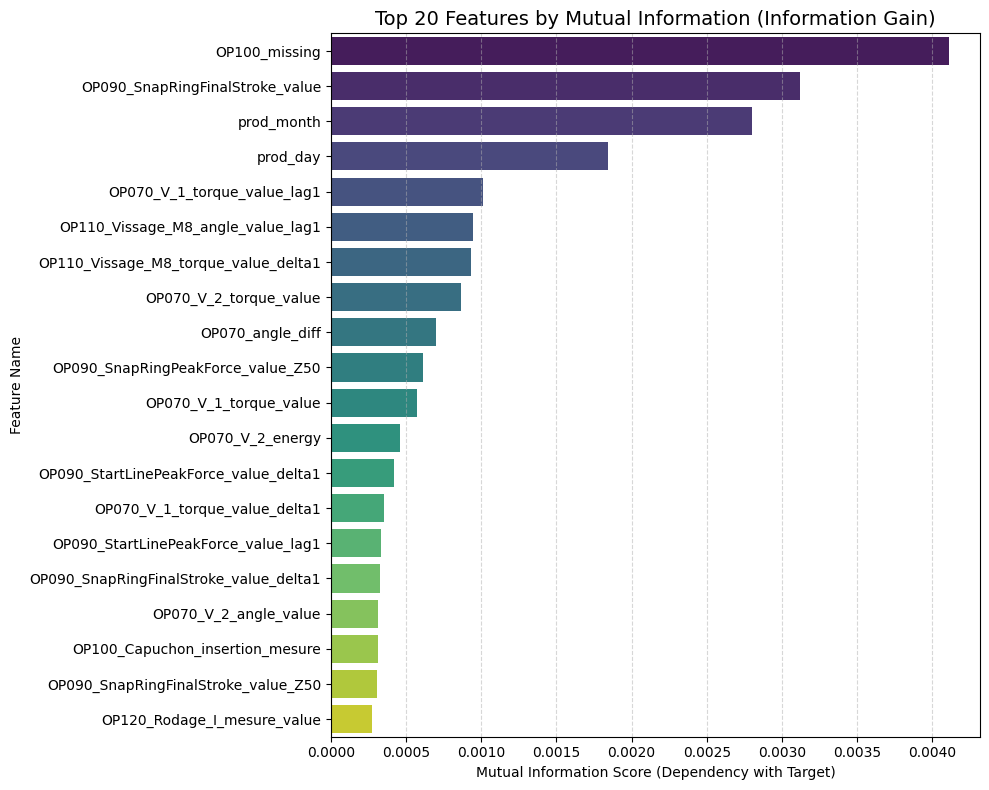

In [71]:
mi_scores = mutual_info_classif(X_train_engineered, y_train, discrete_features='auto', random_state=42)
mi_df = pd.DataFrame({'Feature': X_train_engineered.columns, 'Score': mi_scores}).sort_values('Score', ascending=False)

top_20_features = mi_df['Feature'].head(20).tolist()
X_train_reduced = X_train_engineered[top_20_features].copy()
X_val_reduced = X_val_engineered[top_20_features].copy()
X_test_reduced = X_test_engineered[top_20_features].copy()

plt.figure(figsize=(10, 8))
sns.barplot(data=mi_df.head(20), x='Score', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title("Top 20 Features by Mutual Information (Information Gain)", fontsize=14)
plt.xlabel("Mutual Information Score (Dependency with Target)")
plt.ylabel("Feature Name")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Displays all datasets along with their number of rows and features (shape).

In [72]:
from IPython.display import display

for name, (X_t, X_v, X_te) in datasets.items():
    print(f"DATASET: '{name.upper()}'")
    print(f"- Train Shape: {X_t.shape}")
    print(f"- Val Shape:   {X_v.shape}")
    print(f"- Test Shape:  {X_te.shape}")
    print(f"- Features ({len(X_t.columns)}):")
    
    print(f"\n   Preview (First 5 Rows of Training Data):")
    display(X_t.head(5))
    
    print("\n" + "="*80 + "\n")

DATASET: 'BASELINE'
- Train Shape: (24160, 13)
- Val Shape:   (5177, 13)
- Test Shape:  (5178, 13)
- Features (13):

   Preview (First 5 Rows of Training Data):


,OP070_V_1_angle_value,OP090_SnapRingPeakForce_value,OP070_V_2_angle_value,OP120_Rodage_I_mesure_value,OP090_SnapRingFinalStroke_value,OP110_Vissage_M8_torque_value,OP100_Capuchon_insertion_mesure,OP120_Rodage_U_mesure_value,OP070_V_1_torque_value,OP090_StartLinePeakForce_value,OP110_Vissage_M8_angle_value,OP090_SnapRingMidPointForce_val,OP070_V_2_torque_value
0,154.5,142.39,165.8,116.14,11.83,12.26,0.39,11.97,6.60,23.66,17.0,101.64,6.60
5,157.8,148.33,170.0,109.30,11.90,12.38,0.39,11.97,6.62,22.77,18.7,93.14,6.60
1,166.3,182.57,196.2,113.41,12.07,12.23,0.39,11.97,6.60,25.04,21.4,105.05,6.60
3,164.3,181.92,153.2,113.44,12.05,12.31,0.39,11.97,6.61,26.43,36.6,110.69,6.64
4,169.1,167.53,150.6,116.36,11.97,12.20,0.39,11.97,6.63,22.23,19.3,94.15,6.60




DATASET: 'RAW_SCALED'
- Train Shape: (24160, 13)
- Val Shape:   (5177, 13)
- Test Shape:  (5178, 13)
- Features (13):

   Preview (First 5 Rows of Training Data):


,OP070_V_1_angle_value,OP090_SnapRingPeakForce_value,OP070_V_2_angle_value,OP120_Rodage_I_mesure_value,OP090_SnapRingFinalStroke_value,OP110_Vissage_M8_torque_value,OP100_Capuchon_insertion_mesure,OP120_Rodage_U_mesure_value,OP070_V_1_torque_value,OP090_StartLinePeakForce_value,OP110_Vissage_M8_angle_value,OP090_SnapRingMidPointForce_val,OP070_V_2_torque_value
0,-0.186047,-0.922009,0.333333,0.643146,-0.333333,0.000000,0.0,0.0,-0.05,-0.168317,0.106061,0.357520,-0.055556
5,-0.032558,-0.529412,0.545455,-0.939271,-0.041667,1.333333,0.0,0.0,0.05,-0.462046,0.363636,-0.763852,-0.055556
1,0.362791,1.733642,1.868687,0.011567,0.666667,-0.333333,0.0,0.0,-0.05,0.287129,0.772727,0.807388,-0.055556
3,0.269767,1.690681,-0.303030,0.018508,0.583333,0.555556,0.0,0.0,0.00,0.745875,3.075758,1.551451,0.166667
4,0.493023,0.739590,-0.434343,0.694043,0.250000,-0.666667,0.0,0.0,0.10,-0.640264,0.454545,-0.630607,-0.055556




DATASET: 'ENGINEERED'
- Train Shape: (24160, 48)
- Val Shape:   (5177, 48)
- Test Shape:  (5178, 48)
- Features (48):

   Preview (First 5 Rows of Training Data):


...

,prod_year,prod_month,prod_day
0,2019.0,7.0,13.0
5,2019.0,5.0,31.0
1,2019.0,4.0,29.0
3,2019.0,5.0,4.0
4,2019.0,5.0,13.0




DATASET: 'REDUCED'
- Train Shape: (24160, 20)
- Val Shape:   (5177, 20)
- Test Shape:  (5178, 20)
- Features (20):

   Preview (First 5 Rows of Training Data):


,OP100_missing,OP090_SnapRingFinalStroke_value,prod_month,prod_day,OP070_V_1_torque_value_lag1,OP110_Vissage_M8_angle_value_lag1,OP110_Vissage_M8_torque_value_delta1,OP070_V_2_torque_value,OP070_angle_diff,OP090_SnapRingPeakForce_value_Z50,OP070_V_1_torque_value,OP070_V_2_energy,OP090_StartLinePeakForce_value_delta1,OP070_V_1_torque_value_delta1,OP090_StartLinePeakForce_value_lag1,OP090_SnapRingFinalStroke_value_delta1,OP070_V_2_angle_value,OP100_Capuchon_insertion_mesure,OP090_SnapRingFinalStroke_value_Z50,OP120_Rodage_I_mesure_value
0,0.0,-0.333333,0.000000,0.000000,0.00,0.000000,0.000000,-0.055556,-0.098160,0.0,-0.05,0.363777,0.000000,0.0,0.000000,0.000000,0.333333,0.0,0.0,0.643146
5,0.0,-0.041667,-0.666667,0.818182,-0.05,0.772727,1.250000,-0.055556,-0.042945,0.0,0.05,0.568573,-0.500000,0.5,0.287129,-0.566667,0.545455,0.0,0.0,-0.939271
1,0.0,0.666667,-1.000000,0.727273,0.05,3.181818,0.166667,-0.055556,1.042945,0.0,-0.05,1.846104,0.915929,-0.5,-1.075908,-0.033333,1.868687,0.0,0.0,0.011567
3,0.0,0.583333,-0.666667,-0.409091,0.10,0.454545,0.916667,0.166667,-0.110429,0.0,0.00,-0.205335,0.931416,-0.5,-0.640264,0.266667,-0.303030,0.0,0.0,0.018508
4,0.0,0.250000,-0.666667,0.000000,0.20,-1.045455,-1.666667,-0.055556,0.343558,0.0,0.10,-0.377386,-0.033186,-0.5,-0.587459,-0.300000,-0.434343,0.0,0.0,0.694043




DATASET: 'PCA'
- Train Shape: (24160, 4)
- Val Shape:   (5177, 4)
- Test Shape:  (5178, 4)
- Features (4):

   Preview (First 5 Rows of Training Data):


,PCA_1,PCA_2,PCA_3,PCA_4
0,0.087073,-0.235516,0.239625,0.224310
5,-0.711309,-0.393802,0.046512,-1.129370
1,1.576805,0.390917,1.370067,0.091794
3,2.703196,1.680615,-0.552095,0.046764
4,-0.027596,0.662856,0.035813,0.897714


Explained Variance: 28.44%


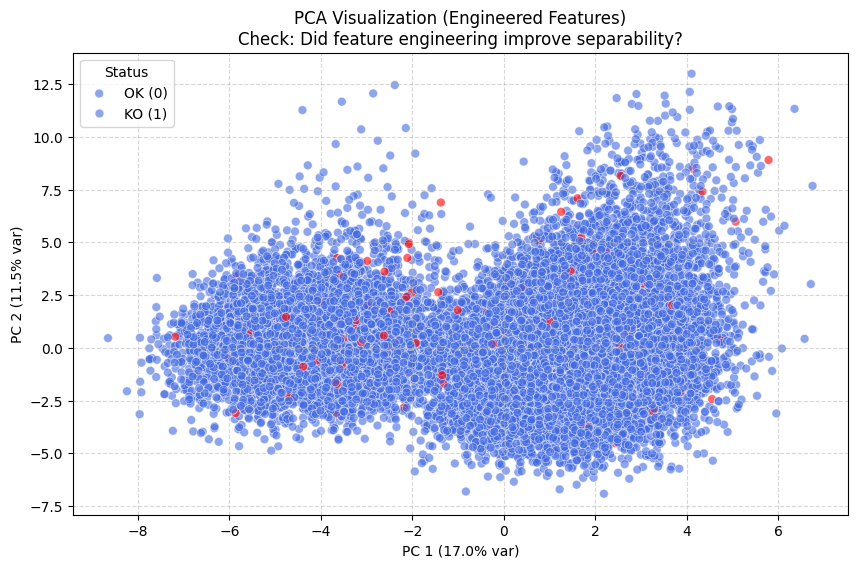

In [73]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler 

X_vis = X_train_engineered.copy()
y_vis = y_train.copy()

scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis_scaled)

print(f"Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=y_vis, 
    palette={0: "royalblue", 1: "red"}, 
    alpha=0.6,
    edgecolor="w",
    s=40
)
plt.title("PCA Visualization (Engineered Features)\nCheck: Did feature engineering improve separability?")
plt.xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.legend(title="Status", labels=["OK (0)", "KO (1)"])
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 4. Model experiments

## 4.1 Logistic Regression (Baseline)

In [74]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

# to reduce compute time in case not all data sets should be tested 
target_datasets = ['baseline', 'raw_scaled', 'engineered', 'reduced', 'PCA']
datasets_to_test = {k: v for k, v in datasets.items() if k in target_datasets}

C_values = [0.0022, 0.0025, 0.00027, 0.1, 0.5, 0.01, 1.0, 10.0] # regularization strength
thresholds = [0.45, 0.5, 0.55, 0.6, 0.65]

results_tuning = []

print(f"Starting Grid Search on: {list(datasets_to_test.keys())}")

# loop to test alle combinations
for name, (X_tr, X_v, X_te) in datasets_to_test.items():
    for c_val in C_values:
        pipeline = Pipeline([
            ('scaler', StandardScaler()), 
            ('classifier', LogisticRegression(
                penalty='l2',           
                solver='lbfgs',         
                C=c_val,                
                class_weight='balanced',
                max_iter=5000, 
                random_state=42,
                n_jobs=-1
            ))
        ])

        try:
            pipeline.fit(X_tr, y_train)
            
            y_prob = pipeline.predict_proba(X_v)[:, 1]

            roc = roc_auc_score(y_val, y_prob)
            pr_auc = average_precision_score(y_val, y_prob)
            
            clf = pipeline.named_steps['classifier']
            n_selected = np.sum(clf.coef_ != 0)

            for thresh in thresholds:
                y_pred_thresh = (y_prob >= thresh).astype(int)
                f1 = f1_score(y_val, y_pred_thresh)
                
                results_tuning.append({
                    'Dataset': name,
                    'C': c_val,
                    'Threshold': thresh,
                    'ROC-AUC': round(roc, 4),      
                    'PR-AUC': round(pr_auc, 4),    
                    'F1': round(f1, 4),
                    'Feat. Used': n_selected
                })
            
        except Exception as e:
            print(f"Error on {name} with C={c_val}: {e}")

df_tuning = pd.DataFrame(results_tuning)
df_tuning = df_tuning.sort_values(by=['ROC-AUC', 'F1'], ascending=False).reset_index(drop=True)

print("\n--- Top 10 Results ---")
display(df_tuning.head(10))

print("\n--- Best Result per Dataset ---")
display(df_tuning.sort_values('ROC-AUC', ascending=False).groupby('Dataset').head(1))

best_overall = df_tuning.iloc[0]

print("\n--- FINAL SELECTION ---")
if best_overall['Dataset'] == 'temporal':
    print(f"Best overall was 'temporal' (ROC: {best_overall['ROC-AUC']}). Skipping as requested.")
    
    df_non_temporal = df_tuning[df_tuning['Dataset'] != 'temporal']
    if not df_non_temporal.empty:
        best_model = df_non_temporal.iloc[0]
        print(f"Selected Best Non-Temporal Model: {best_model['Dataset']}")
        print(f"C: {best_model['C']}, Threshold: {best_model['Threshold']}")
        print(f"Metrics -> ROC-AUC: {best_model['ROC-AUC']}, F1: {best_model['F1']}")
    else:
        print("No non-temporal models found.")
else:
    print(f"Selected Best Model: {best_overall['Dataset']}")
    print(f"C: {best_overall['C']}, Threshold: {best_overall['Threshold']}")
    print(f"Metrics -> ROC-AUC: {best_overall['ROC-AUC']}, F1: {best_overall['F1']}")

Starting Grid Search on: ['baseline', 'raw_scaled', 'engineered', 'reduced', 'PCA']

--- Top 10 Results ---


,Dataset,C,Threshold,ROC-AUC,PR-AUC,F1,Feat. Used
0,engineered,0.00027,0.65,0.7012,0.0336,0.0596,48
1,engineered,0.00027,0.60,0.7012,0.0336,0.0552,48
2,engineered,0.00027,0.55,0.7012,0.0336,0.0519,48
3,engineered,0.00027,0.50,0.7012,0.0336,0.0438,48
4,engineered,0.00027,0.45,0.7012,0.0336,0.0344,48
5,engineered,0.00220,0.60,0.6893,0.0336,0.0516,48
6,engineered,0.00220,0.65,0.6893,0.0336,0.0486,48
7,engineered,0.00220,0.55,0.6893,0.0336,0.0473,48
8,engineered,0.00220,0.50,0.6893,0.0336,0.0405,48
9,engineered,0.00220,0.45,0.6893,0.0336,0.0339,48



--- Best Result per Dataset ---


,Dataset,C,Threshold,ROC-AUC,PR-AUC,F1,Feat. Used
0,engineered,0.00027,0.65,0.7012,0.0336,0.0596,48
15,reduced,0.00220,0.55,0.6885,0.0304,0.0449,20
35,baseline,0.00027,0.50,0.6829,0.0283,0.0437,13
32,raw_scaled,0.00027,0.55,0.6829,0.0310,0.0501,13
163,PCA,0.00250,0.60,0.5211,0.0119,0.0000,4



--- FINAL SELECTION ---
Selected Best Model: engineered
C: 0.00027, Threshold: 0.65
Metrics -> ROC-AUC: 0.7012, F1: 0.0596


Training final model on 'engineered' dataset...

--- Top 15 Influential Features ---


,Feature,Coefficient,Abs_Importance
0,OP070_V_2_torque_value,-0.120628,0.120628
1,OP090_StartLinePeakForce_value,0.114950,0.114950
2,OP090_StartLinePeakForce_value_Z50,0.114285,0.114285
3,OP100_missing,-0.107379,0.107379
4,OP070_V_1_torque_value,-0.082794,0.082794
5,OP070_V_1_torque_value_Z50,-0.080598,0.080598
6,OP070_torque_diff,-0.072005,0.072005
7,OP070_V_1_torque_value_delta1,-0.068221,0.068221
8,prod_month,0.065905,0.065905
9,OP090_SnapRingMidPointForce_val,0.064848,0.064848


/var/folders/l3/x8z60lyd2yj23s6rjdy757dr0000gn/T/ipykernel_55911/2593257713.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




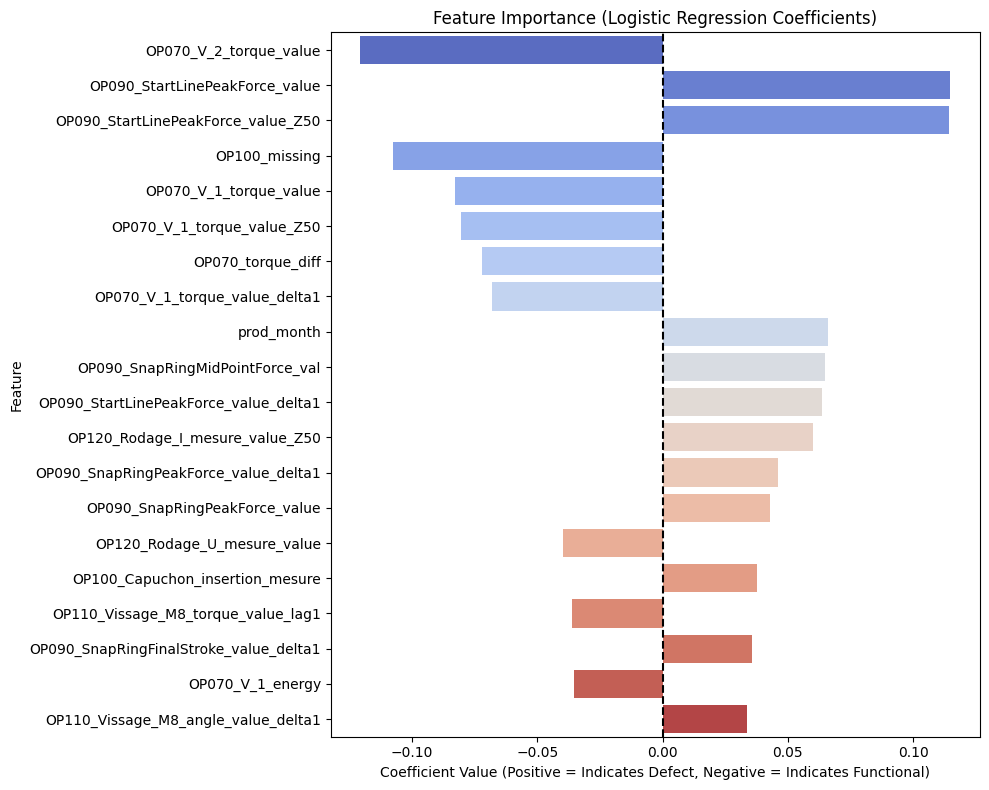

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


X_train_eng, X_val_eng, _ = datasets['engineered']

if hasattr(X_train_eng, 'columns'):
    feature_names = X_train_eng.columns
else:
   
    feature_names = [f"Feature_{i}" for i in range(X_train_eng.shape[1])]

best_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('classifier', LogisticRegression(
        penalty='l2',           
        solver='lbfgs',         
        C=0.00027,                
        class_weight='balanced',
        max_iter=5000, 
        random_state=42,
        n_jobs=-1
    ))
])


print("Training final model on 'engineered' dataset...")
best_pipeline.fit(X_train_eng, y_train)

classifier = best_pipeline.named_steps['classifier']
coefs = classifier.coef_[0]

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Abs_Importance': np.abs(coefs) # Betrag für Sortierung
})

df_importance = df_importance.sort_values(by='Abs_Importance', ascending=False).reset_index(drop=True)


print("\n--- Top 15 Influential Features ---")
display(df_importance.head(15))

plt.figure(figsize=(10, 8))
top_20 = df_importance.head(20)

sns.barplot(x='Coefficient', y='Feature', data=top_20, palette='coolwarm')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Positive = Indicates Defect, Negative = Indicates Functional)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

## 4.2 Logistic Regression (Elastic Net)

In [76]:
import pandas as pd
import numpy as np
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.exceptions import ConvergenceWarning

# to reduce compute time in case not all data sets should be tested 
target_datasets = ['baseline', 'raw_scaled', 'engineered', 'reduced', 'PCA']
datasets_to_test = {k: v for k, v in datasets.items() if k in target_datasets}


C_values = sorted([50, 100, 120, 150, 200]) # regularization 
l1_ratios = [0.6, 0.85, 0.9, 0.95] # l1 enforces more sparsity 
thresholds = [0.45, 0.5, 0.55, 0.6, 0.65]

results_tuning_en = []

print(f"Starting Optimized Grid Search (ElasticNet) on: {list(datasets_to_test.keys())}")

# for clean output 
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning)

    for name, (X_tr, X_v, X_te) in datasets_to_test.items():
        print(f"Processing {name}...")
        
        scaler = StandardScaler()
        if hasattr(X_tr, 'values'):
            X_tr_scaled = scaler.fit_transform(X_tr.values)
            X_v_scaled = scaler.transform(X_v.values)
        else:
            X_tr_scaled = scaler.fit_transform(X_tr)
            X_v_scaled = scaler.transform(X_v)
        
        for l1_val in l1_ratios:
            
            clf = LogisticRegression(
                penalty='elasticnet',
                solver='saga',          
                l1_ratio=l1_val,
                class_weight='balanced', 
                warm_start=True,       
                max_iter=2000,         
                tol=1e-3,              
                random_state=42,
                n_jobs=-1
            )
            for c_val in C_values:
                try:
                    clf.set_params(C=c_val)
                    clf.fit(X_tr_scaled, y_train)
                    
                    y_prob = clf.predict_proba(X_v_scaled)[:, 1]

                    roc = roc_auc_score(y_val, y_prob)
                    pr_auc = average_precision_score(y_val, y_prob)
                    n_selected = np.sum(clf.coef_ != 0)

                    for thresh in thresholds:
                        y_pred_thresh = (y_prob >= thresh).astype(int)
                        f1 = f1_score(y_val, y_pred_thresh)
                        
                        results_tuning_en.append({
                            'Dataset': name,
                            'C': c_val,
                            'L1_Ratio': l1_val,
                            'Threshold': thresh,
                            'ROC-AUC': round(roc, 4),      
                            'PR-AUC': round(pr_auc, 4),    
                            'F1': round(f1, 4),
                            'Feat. Used': n_selected
                        })
                    
                except Exception as e:
                    pass

# Create DataFrame
df_tuning_en = pd.DataFrame(results_tuning_en)
df_tuning_en = df_tuning_en.sort_values(by=['ROC-AUC', 'F1'], ascending=False).reset_index(drop=True)

print("\n--- Top 10 Tuning Results (ElasticNet) ---")
display(df_tuning_en.head(10))

print("\n--- Best Result per Dataset ---")
display(df_tuning_en.sort_values('ROC-AUC', ascending=False).groupby('Dataset').head(1))

# Final Selection logic
if not df_tuning_en.empty:
    best_model_en = df_tuning_en.iloc[0]
    print(f"\n--- FINAL SELECTION (ElasticNet) ---")
    print(f"Selected Dataset: {best_model_en['Dataset']}")
    print(f"Parameters: C={best_model_en['C']}, L1_Ratio={best_model_en['L1_Ratio']}, Threshold={best_model_en['Threshold']}")
    print(f"Metrics -> ROC-AUC: {best_model_en['ROC-AUC']}, F1: {best_model_en['F1']}")
else:
    print("No results found.")

Starting Optimized Grid Search (ElasticNet) on: ['baseline', 'raw_scaled', 'engineered', 'reduced', 'PCA']
Processing baseline...
Processing raw_scaled...
Processing engineered...
Processing reduced...
Processing PCA...

--- Top 10 Tuning Results (ElasticNet) ---


,Dataset,C,L1_Ratio,Threshold,ROC-AUC,PR-AUC,F1,Feat. Used
0,engineered,100,0.6,0.60,0.6943,0.0253,0.0361,48
1,engineered,100,0.6,0.65,0.6943,0.0253,0.0361,48
2,engineered,100,0.6,0.50,0.6943,0.0253,0.0356,48
3,engineered,100,0.6,0.55,0.6943,0.0253,0.0350,48
4,engineered,100,0.6,0.45,0.6943,0.0253,0.0346,48
5,baseline,50,0.6,0.65,0.6796,0.0273,0.0557,13
6,baseline,100,0.6,0.65,0.6796,0.0272,0.0557,13
7,baseline,120,0.6,0.65,0.6796,0.0273,0.0557,13
8,baseline,150,0.6,0.65,0.6796,0.0273,0.0557,13
9,baseline,200,0.6,0.65,0.6796,0.0273,0.0557,13



--- Best Result per Dataset ---


,Dataset,C,L1_Ratio,Threshold,ROC-AUC,PR-AUC,F1,Feat. Used
0,engineered,100,0.60,0.60,0.6943,0.0253,0.0361,48
69,baseline,200,0.60,0.55,0.6796,0.0273,0.0405,13
105,reduced,100,0.95,0.65,0.6788,0.0258,0.0311,20
115,raw_scaled,120,0.90,0.65,0.6625,0.0219,0.0384,13
335,PCA,200,0.95,0.65,0.5579,0.0114,0.0244,4



--- FINAL SELECTION (ElasticNet) ---
Selected Dataset: engineered
Parameters: C=100, L1_Ratio=0.6, Threshold=0.6
Metrics -> ROC-AUC: 0.6943, F1: 0.0361


## 4.3 One-Class SVM

In [77]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

target_datasets = ['baseline', 'raw_scaled', 'engineered', 'reduced', 'PCA']
datasets_to_test = {k: v for k, v in datasets.items() if k in target_datasets}

param_grid = {
    'model__nu': [0.005, 0.01, 0.05, 0.1],
    'model__gamma': ['scale', 'auto', 0.06, 0.08],
    'model__kernel': ['rbf']
}

results_ocsvm = []

print(f"Starting One-Class SVM Grid Search on: {list(datasets_to_test.keys())}...")

for name, (X_tr, X_v, X_te) in datasets_to_test.items():
    
    X_tr_pure = X_tr[y_train == 0]
    
    for params in ParameterGrid(param_grid):
        pipeline = Pipeline([
            ('scaler', StandardScaler()), 
            ('model', OneClassSVM(cache_size=2000))
        ])
        
        pipeline.set_params(**params)

        try:
            pipeline.fit(X_tr_pure)
        
            y_scores = -pipeline.decision_function(X_v)

            roc = roc_auc_score(y_val, y_scores)
            pr_auc = average_precision_score(y_val, y_scores)
            
            results_ocsvm.append({
                'Dataset': name,
                'Nu': params['model__nu'],
                'Gamma': params['model__gamma'],
                'Kernel': params['model__kernel'],
                'ROC-AUC': round(roc, 4),
                'PR-AUC': round(pr_auc, 4)
            })
            
        except Exception as e:
            pass

df_ocsvm = pd.DataFrame(results_ocsvm).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("\n--- Top 10 One-Class SVM Results ---")
display(df_ocsvm.head(10))

print("\n--- Best Result per Dataset ---")
display(df_ocsvm.sort_values('ROC-AUC', ascending=False).groupby('Dataset').head(1))

if not df_ocsvm.empty:
    best_model_oc = df_ocsvm.iloc[0]
    print(f"\n--- FINAL SELECTION (One-Class SVM) ---")
    print(f"Selected Dataset: {best_model_oc['Dataset']}")
    print(f"Parameters: Nu={best_model_oc['Nu']}, Gamma={best_model_oc['Gamma']}, Kernel={best_model_oc['Kernel']}")
    print(f"Metrics -> ROC-AUC: {best_model_oc['ROC-AUC']}, PR-AUC: {best_model_oc['PR-AUC']}")
else:
    print("No results found.")

Starting One-Class SVM Grid Search on: ['baseline', 'raw_scaled', 'engineered', 'reduced', 'PCA']...

--- Top 10 One-Class SVM Results ---


,Dataset,Nu,Gamma,Kernel,ROC-AUC,PR-AUC
0,PCA,0.005,auto,rbf,0.5506,0.0122
1,PCA,0.005,scale,rbf,0.5506,0.0122
2,PCA,0.010,auto,rbf,0.5446,0.0116
3,PCA,0.010,scale,rbf,0.5446,0.0116
4,baseline,0.100,0.08,rbf,0.5293,0.0107
5,baseline,0.100,scale,rbf,0.5284,0.0107
6,baseline,0.100,auto,rbf,0.5284,0.0107
7,baseline,0.100,0.06,rbf,0.5255,0.0105
8,raw_scaled,0.100,0.08,rbf,0.5240,0.0106
9,raw_scaled,0.100,scale,rbf,0.5234,0.0105



--- Best Result per Dataset ---


,Dataset,Nu,Gamma,Kernel,ROC-AUC,PR-AUC
0,PCA,0.005,auto,rbf,0.5506,0.0122
4,baseline,0.100,0.08,rbf,0.5293,0.0107
8,raw_scaled,0.100,0.08,rbf,0.5240,0.0106
19,engineered,0.005,0.08,rbf,0.5087,0.0104
34,reduced,0.100,scale,rbf,0.4998,0.0115



--- FINAL SELECTION (One-Class SVM) ---
Selected Dataset: PCA
Parameters: Nu=0.005, Gamma=auto, Kernel=rbf
Metrics -> ROC-AUC: 0.5506, PR-AUC: 0.0122


## 4.4 XGBoost with time-series cross-validation

In [78]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

target_datasets = ['raw_scaled', 'reduced'] # ['baseline', 'raw_scaled', 'engineered', 'reduced', 'PCA']
datasets_to_test = {k: v for k, v in datasets.items() if k in target_datasets}

results_final_comparison = []

param_grid_optimized = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.0001, 0.001, 0.01], # [0.01, 0.05, 0.1],
    'n_estimators': [150, 200, 250],
    'min_child_weight': [1,3, 5],
    'scale_pos_weight': [1, 3, 5, 20],
    'subsample': [0.7, 0.6],
    'colsample_bytree': [0.8, 0.9]
}

tscv = TimeSeriesSplit(n_splits=3)

print(f"Starting XGBoost Grid Search on: {list(datasets_to_test.keys())}")

for name, (X_tr, X_v, X_te) in datasets_to_test.items():
    
    xgb = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1,
        tree_method='hist'
    )

    grid = GridSearchCV(
        estimator=xgb,
        param_grid=param_grid_optimized,
        scoring='average_precision',
        cv=tscv,
        n_jobs=-1
    )

    try:
        grid.fit(X_tr, y_train)
        
        best_model = grid.best_estimator_
        y_prob = best_model.predict_proba(X_v)[:, 1]
        
        roc = roc_auc_score(y_val, y_prob)
        pr = average_precision_score(y_val, y_prob)

        res_entry = {
            'Dataset': name,
            'ROC-AUC': round(roc, 4),
            'PR-AUC': round(pr, 4),
            'Best Params': grid.best_params_
        }
        results_final_comparison.append(res_entry)
        
    except Exception as e:
        print(f"Error on {name}: {e}")

df_results_final = pd.DataFrame(results_final_comparison).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("\n--- Final XGBoost Results ---")
pd.set_option('display.max_colwidth', None)
display(df_results_final)

if not df_results_final.empty:
    best_model_xgb = df_results_final.iloc[0]
    print(f"\n--- FINAL SELECTION (XGBoost) ---")
    print(f"Selected Dataset: {best_model_xgb['Dataset']}")
    print(f"Metrics -> ROC-AUC: {best_model_xgb['ROC-AUC']}, PR-AUC: {best_model_xgb['PR-AUC']}")
    print(f"Params: {best_model_xgb['Best Params']}")
else:
    print("No results found.")

Starting XGBoost Grid Search on: ['raw_scaled', 'reduced']

--- Final XGBoost Results ---


,Dataset,ROC-AUC,PR-AUC,Best Params
0,reduced,0.6793,0.0255,"{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 150, 'scale_pos_weight': 1, 'subsample': 0.7}"
1,raw_scaled,0.6671,0.0396,"{'colsample_bytree': 0.8, 'learning_rate': 0.0001, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 250, 'scale_pos_weight': 1, 'subsample': 0.6}"



--- FINAL SELECTION (XGBoost) ---
Selected Dataset: reduced
Metrics -> ROC-AUC: 0.6793, PR-AUC: 0.0255
Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 150, 'scale_pos_weight': 1, 'subsample': 0.7}


## 4.5 Autoencoder

Epoch [1/60] - Train Loss: 0.670651 - Val Loss: 0.785163
Epoch [10/60] - Train Loss: 0.019072 - Val Loss: 0.010517
Epoch [20/60] - Train Loss: 0.002347 - Val Loss: 0.001878
Epoch [30/60] - Train Loss: 0.001149 - Val Loss: 0.000969
Epoch [40/60] - Train Loss: 0.000751 - Val Loss: 0.000510
Epoch [50/60] - Train Loss: 0.000540 - Val Loss: 0.000317
Epoch [60/60] - Train Loss: 0.000426 - Val Loss: 0.000228


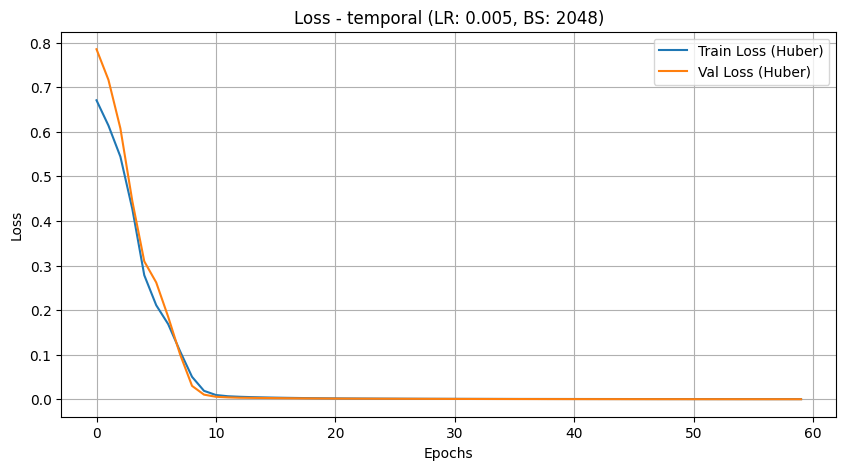

Epoch [1/60] - Train Loss: 0.698627 - Val Loss: 0.845872
Epoch [10/60] - Train Loss: 0.592238 - Val Loss: 0.728976
Epoch [20/60] - Train Loss: 0.288863 - Val Loss: 0.391869
Epoch [30/60] - Train Loss: 0.243745 - Val Loss: 0.342164
Epoch [40/60] - Train Loss: 0.240251 - Val Loss: 0.338426
Epoch [50/60] - Train Loss: 0.236441 - Val Loss: 0.334753
Epoch [60/60] - Train Loss: 0.210754 - Val Loss: 0.289322


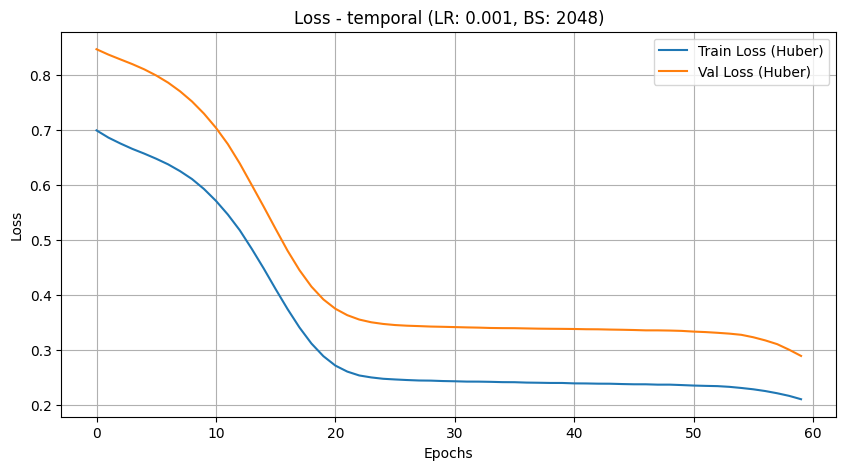

Epoch [1/60] - Train Loss: 0.564371 - Val Loss: 0.428187
Epoch [10/60] - Train Loss: 0.001840 - Val Loss: 0.000813
Epoch [20/60] - Train Loss: 0.000358 - Val Loss: 0.000210
Epoch [30/60] - Train Loss: 0.000120 - Val Loss: 0.000104
Epoch [40/60] - Train Loss: 0.000076 - Val Loss: 0.000061
Epoch [50/60] - Train Loss: 0.000056 - Val Loss: 0.000049
Epoch [60/60] - Train Loss: 0.000044 - Val Loss: 0.000035


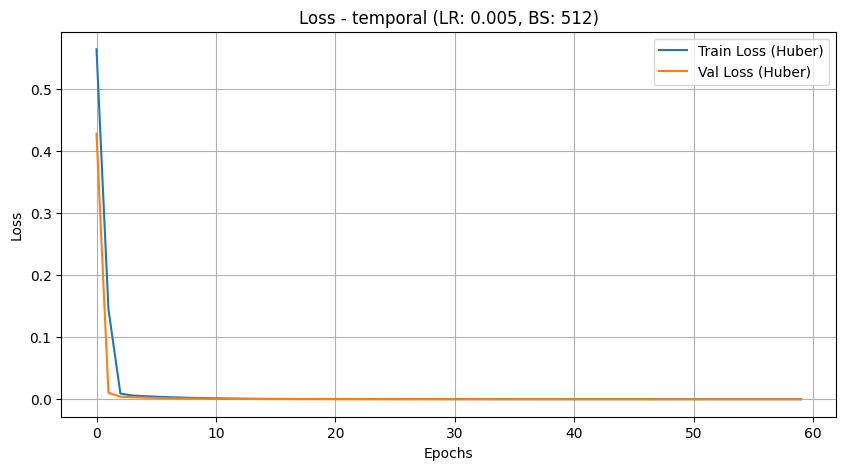

Epoch [1/60] - Train Loss: 0.679849 - Val Loss: 0.797313
Epoch [10/60] - Train Loss: 0.041322 - Val Loss: 0.047571
Epoch [20/60] - Train Loss: 0.005969 - Val Loss: 0.004378
Epoch [30/60] - Train Loss: 0.001778 - Val Loss: 0.001483
Epoch [40/60] - Train Loss: 0.000684 - Val Loss: 0.000638
Epoch [50/60] - Train Loss: 0.000387 - Val Loss: 0.000380
Epoch [60/60] - Train Loss: 0.000257 - Val Loss: 0.000261


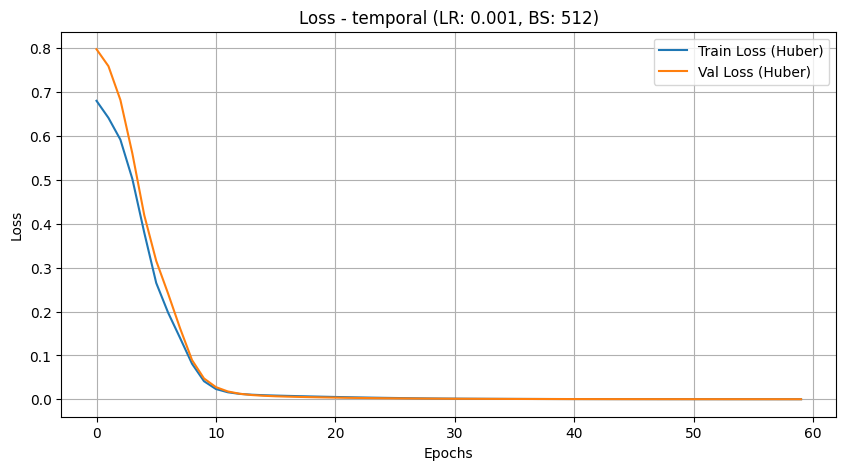

,Dataset,LR,Batch_Size,PR-AUC,ROC-AUC
3,temporal,0.001,512,0.009,0.442
1,temporal,0.001,2048,0.009,0.414
0,temporal,0.005,2048,0.009,0.398
2,temporal,0.005,512,0.009,0.367


In [79]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score, average_precision_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Device Konfiguration
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.LeakyReLU(),
            nn.Linear(8, 4),
            nn.Sigmoid()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.LeakyReLU(),
            nn.Linear(8, input_dim)  
        )
        
        # doesn't bring significant advantages 
        """# He-Initialization 
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)"""

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Hyperparameter 
param_grid = {
    'lr': [0.005, 0.001],
    'batch_size': [2048, 512],
    'epochs': [60]
}

results_ae = []

for name, (X_tr, X_v, X_te) in datasets.items():
    if name == "temporal":
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_v_scaled = scaler.transform(X_v)
        
        # Training only on "ok" data 
        X_tr_ok = X_tr_scaled[y_train == 0]
        X_tr_tensor = torch.tensor(X_tr_ok, dtype=torch.float32).to(device)
        X_v_tensor = torch.tensor(X_v_scaled, dtype=torch.float32).to(device)

        for params in ParameterGrid(param_grid):
            train_loader = DataLoader(
                TensorDataset(X_tr_tensor), 
                batch_size=params['batch_size'], 
                shuffle=True
            )

            model = Autoencoder(input_dim=X_tr.shape[1]).to(device)
            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=params['lr'])

            # loss history 
            train_losses = []
            val_losses = []

            for epoch in range(params['epochs']):
                # Training 
                model.train()
                batch_losses = []
                for batch in train_loader:
                    inputs = batch[0]
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, inputs)
                    loss.backward()
                    optimizer.step()
                    batch_losses.append(loss.item())
                
                avg_train_loss = np.mean(batch_losses)
                train_losses.append(avg_train_loss)

                # valdidation mode
                model.eval()
                with torch.no_grad():
                    v_outputs = model(X_v_tensor)
                    v_loss = criterion(v_outputs, X_v_tensor)
                    val_losses.append(v_loss.item())
                
                if (epoch + 1) % 10 == 0 or epoch == 0:
                    print(f"Epoch [{epoch+1}/{params['epochs']}] - Train Loss: {avg_train_loss:.6f} - Val Loss: {v_loss.item():.6f}")

            # loss curve
            plt.figure(figsize=(10, 5))
            plt.plot(train_losses, label='Train Loss (Huber)')
            plt.plot(val_losses, label='Val Loss (Huber)')
            plt.title(f"Loss - {name} (LR: {params['lr'] }, BS: {params['batch_size']})")
            plt.xlabel("Epochs")
            plt.ylabel("Loss")
            plt.legend()
            plt.grid(True)
            plt.show()

            model.eval()
            with torch.no_grad():
                reconstructions = model(X_v_tensor)
                errors = torch.mean((X_v_tensor - reconstructions) ** 2, dim=1).cpu().numpy()

            roc_auc = roc_auc_score(y_val, errors)
            pr_auc = average_precision_score(y_val, errors)

            results_ae.append({
                'Dataset': name, 'LR': params['lr'], 'Batch_Size': params['batch_size'],
                'PR-AUC': round(pr_auc, 3), 'ROC-AUC': round(roc_auc, 3)
            })

df_ae_results = pd.DataFrame(results_ae).sort_values(by='ROC-AUC', ascending=False)
display(df_ae_results.head(15))

# 68 mit 0.0001 und 256 und RELU
# 58 mit 0.00005 und 1028 und RELU

NaNs in Status column: 0
   Latent_1  Latent_2  Latent_3  Latent_4 Status
0  0.196824  0.220222  0.156895  0.096046     OK
1  0.284894  0.734077  0.160361  0.544684     OK
2  0.575235  0.273809  0.511590  0.160248     OK
3  0.935382  0.761261  0.873761  0.780096     OK
4  0.839732  0.224606  0.858112  0.248234     OK


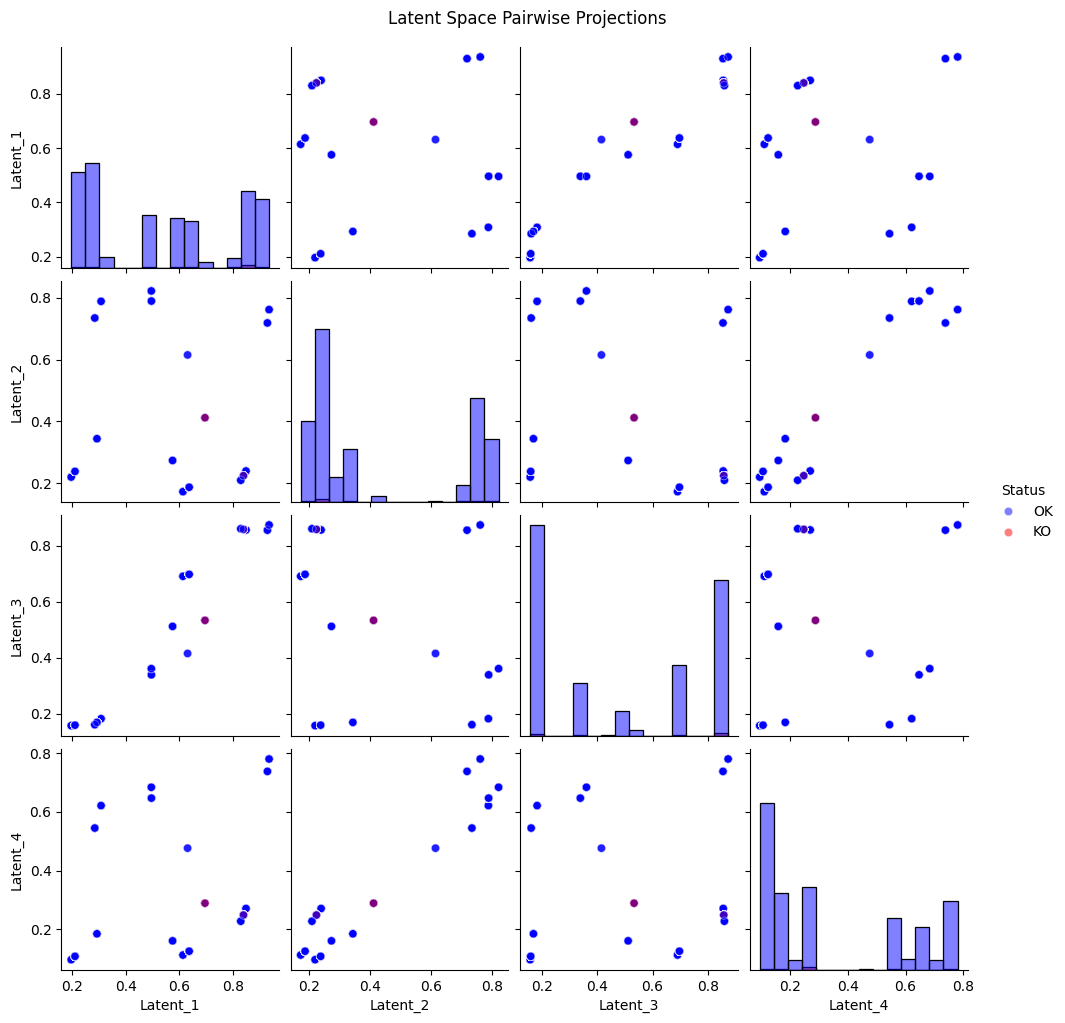

In [80]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    # Pass data through the encoder only
    latent_vectors = model.encoder(X_v_tensor).cpu().numpy()


import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Create the DataFrame from latent vectors
df_latent = pd.DataFrame(latent_vectors, columns=['Latent_1', 'Latent_2', 'Latent_3', 'Latent_4'])

if hasattr(y_val, 'values'):
    status_array = y_val.values 
else:
    status_array = y_val

df_latent['Status'] = status_array

# Map to string labels and handle potential NaNs
df_latent['Status'] = df_latent['Status'].map({0: 'OK', 1: 'KO'})

# debug: check if the data is there
print("NaNs in Status column:", df_latent['Status'].isna().sum()) 
print(df_latent.head())

sns.pairplot(
    df_latent, 
    hue='Status', 
    palette={'OK': 'blue', 'KO': 'red'}, 
    plot_kws={'alpha': 0.5},
    diag_kind='hist' 
)

plt.suptitle("Latent Space Pairwise Projections", y=1.02)
plt.show()

## 4.6 Multilayer perceptron

In [81]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1) 
        )
        
    def forward(self, x):
        return self.net(x)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

target_datasets = ['temporal'] # ['baseline', 'raw_scaled', 'engineered', 'reduced', 'PCA', 'temporal']
datasets_to_test = {k: v for k, v in datasets.items() if k in target_datasets}

param_grid = {
    'lr': [0.001], # [0.0001, 0.001],
    'batch_size': [2048],
    'epochs': [60], 
    'hidden_dim': [32],
    'dropout': [0.1]
}

results_mlp = []
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
weight_val = num_neg / num_pos
pos_weight_tensor = torch.tensor([weight_val], dtype=torch.float32).to(device)

y_tr_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1).to(device)
y_v_tensor_raw = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1).to(device)

print(f"Starting MLP Grid Search on: {list(datasets_to_test.keys())}")

for name, (X_tr, X_v, X_te) in datasets_to_test.items():
    print(f"Processing: {name}...")

    scaler = StandardScaler()
    if hasattr(X_tr, 'values'):
        X_tr_scaled = scaler.fit_transform(X_tr.values)
        X_v_scaled = scaler.transform(X_v.values)
    else:
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_v_scaled = scaler.transform(X_v)
    
    X_tr_tensor = torch.tensor(X_tr_scaled, dtype=torch.float32).to(device)
    X_v_tensor = torch.tensor(X_v_scaled, dtype=torch.float32).to(device)

    for params in ParameterGrid(param_grid):
        
        dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
        train_loader = DataLoader(dataset, batch_size=params['batch_size'], shuffle=True)
        
        model = MLP(input_dim=X_tr.shape[1], hidden_dim=params['hidden_dim'], dropout=params['dropout'])
        model.apply(init_weights)
        model.to(device)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor) 
        optimizer = optim.Adam(model.parameters(), lr=params['lr'])

        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        patience = 15
        patience_counter = 0
        
        for epoch in range(params['epochs']):
            model.train()
            running_loss = 0.0
            for batch_x, batch_y in train_loader:
                optimizer.zero_grad()
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y) 
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            
            avg_train_loss = running_loss / len(train_loader)
            train_losses.append(avg_train_loss)
            
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_v_tensor)
                val_loss = criterion(val_outputs, y_v_tensor_raw)
                val_losses.append(val_loss.item())
            
            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                patience_counter = 0
            else:
                patience_counter += 1
                
            if patience_counter >= patience:
                break

        model.eval()
        with torch.no_grad():
            logits = model(X_v_tensor)
            preds = torch.sigmoid(logits).cpu().numpy() 

        roc_auc = roc_auc_score(y_val, preds)
        pr_auc = average_precision_score(y_val, preds)

        results_mlp.append({
            'Dataset': name,
            'LR': params['lr'],
            'Hidden': params['hidden_dim'],
            'Batch': params['batch_size'],
            'DO': params['dropout'],
            'PR-AUC': round(pr_auc, 4),
            'ROC-AUC': round(roc_auc, 4),
            'Epochs Run': len(train_losses)
        })

df_mlp = pd.DataFrame(results_mlp).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("\n--- Final MLP Results ---")
display(df_mlp.head(10))

if not df_mlp.empty:
    best_overall = df_mlp.iloc[0]
    
    if best_overall['Dataset'] == 'temporal':
        print("\nTemporal was best. Searching for best alternative...")
        df_non_temp = df_mlp[df_mlp['Dataset'] != 'temporal']
        if not df_non_temp.empty:
            best_model_mlp = df_non_temp.iloc[0]
            print(f"Selected Best Non-Temporal MLP: {best_model_mlp['Dataset']}")
        else:
            best_model_mlp = best_overall
    else:
        best_model_mlp = best_overall
        print(f"\nSelected Best MLP: {best_model_mlp['Dataset']}")
        
    print(f"Metrics -> ROC-AUC: {best_model_mlp['ROC-AUC']}, PR-AUC: {best_model_mlp['PR-AUC']}")
    print(f"Params -> Hidden: {best_model_mlp['Hidden']}, LR: {best_model_mlp['LR']}")
else:
    print("No results found.")

Using device: mps
Starting MLP Grid Search on: ['temporal']
Processing: temporal...

--- Final MLP Results ---


,Dataset,LR,Hidden,Batch,DO,PR-AUC,ROC-AUC,Epochs Run
0,temporal,0.001,32,2048,0.1,0.0222,0.6769,23



Temporal was best. Searching for best alternative...
Metrics -> ROC-AUC: 0.6769, PR-AUC: 0.0222
Params -> Hidden: 32, LR: 0.001


# 5. Ensemble and evaluation

## 5.1 Soft-voting ensemble

The strongest linear, boosted-tree, and neural candidates are combined through validation-tuned weights. The section also compares soft and hard voting and selects an operating threshold with Youden's J statistic.

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, f1_score
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
from sklearn.metrics import roc_curve, precision_recall_curve
import torch
from sklearn.isotonic import IsotonicRegression
import pandas as pd

print("--- Ensemble: Soft Voting (4 Models via Grid Search) ---\n")

# --- Model Definitions ---
model_l2 = Pipeline([
    ('scaler', StandardScaler()), 
    ('clf', LogisticRegression(
        penalty='l2', C=0.00027, solver='lbfgs', 
        class_weight='balanced', max_iter=5000, random_state=42
    ))
])

model_en = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='elasticnet', l1_ratio=0.85, solver='saga', 
        class_weight=None, max_iter=6000, random_state=42, C=100
    ))
])

model_xgb = XGBClassifier(
    n_estimators=150,           
    max_depth=5,               
    learning_rate=0.01,       
    scale_pos_weight=39,       
    max_delta_step=1,          
    min_child_weight=3,        
    subsample=0.7,             
    colsample_bytree=0.87,      
    tree_method='hist',        
    random_state=42,           
    n_jobs=-1,                 
    objective="binary:logistic" 
)


# --- Training ---
print("1. Fitting LogReg L2 (on reduced)...")
model_l2.fit(datasets['reduced'][0], y_train)
print("2. Fitting ElasticNet (on reduced)...")
model_en.fit(datasets['reduced'][0], y_train)
print("3. Fitting XGBoost (on Temporal)...")
model_xgb.fit(datasets['temporal'][0], y_train)

# --- Inference & Scaling ---
print("\nCalculating Ensemble Predictions and Scaling...")

p_l2_raw  = model_l2.predict_proba(datasets['reduced'][1])[:, 1] 
p_en_raw  = model_en.predict_proba(datasets['reduced'][1])[:, 1] 
p_xgb_raw = model_xgb.predict_proba(datasets['temporal'][1])[:, 1] 

# Scaling 0-1
scaler_l2 = MinMaxScaler()
p_l2 = scaler_l2.fit_transform(p_l2_raw.reshape(-1, 1)).flatten()

scaler_en = MinMaxScaler()
p_en = scaler_en.fit_transform(p_en_raw.reshape(-1, 1)).flatten()

scaler_xgb = MinMaxScaler()
p_xgb = scaler_xgb.fit_transform(p_xgb_raw.reshape(-1, 1)).flatten()

# MLP Inference
print("Predicting with trained MLP...")
X_mlp_val = datasets['temporal'][1]
X_mlp_scaled = scaler.transform(X_mlp_val) 
X_mlp_tensor = torch.tensor(X_mlp_scaled, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    p_mlp_raw = torch.sigmoid(model(X_mlp_tensor)).cpu().numpy().flatten()

scaler_mlp = MinMaxScaler()
p_mlp = scaler_mlp.fit_transform(p_mlp_raw.reshape(-1, 1)).flatten()

print(f"Rescaled Min/Max L2:  {p_l2.min():.4f} / {p_l2.max():.4f}")
print(f"Rescaled Min/Max EN:  {p_en.min():.4f} / {p_en.max():.4f}")
print(f"Rescaled Min/Max XGB: {p_xgb.min():.4f} / {p_xgb.max():.4f}")
print(f"Rescaled Min/Max MLP: {p_mlp.min():.4f} / {p_mlp.max():.4f}")

# --- Grid Search (Modified for 4 Models) ---
step = 0.05 # Increased step size slightly to prevent excessive runtime (O(n^3))
weight_range = np.arange(0.0, 1.0 + step, step)

best_score = -1
best_weights = (0, 0, 0, 0) # L2, EN, XGB, MLP
best_proba = None

print("\nStarting Grid Search (L2, EN, XGB loops)...")

# Loop L2
for w_l2 in weight_range:
    
    # Loop EN
    for w_en in weight_range:
        if (w_l2 + w_en) > 1.0: break 
        
        # Loop XGB 
        for w_xgb in weight_range:
            if (w_l2 + w_en + w_xgb) > 1.0: break

            # MLP is the remainder
            w_mlp = 1.0 - w_l2 - w_en - w_xgb
            
            # Avoid floating point errors slightly below 0
            if w_mlp < -1e-9: continue
            
            # Weighted Average
            current_proba = (w_l2 * p_l2) + (w_en * p_en) + (w_xgb * p_xgb) + (w_mlp * p_mlp)
            
            score = roc_auc_score(y_val, current_proba)
            
            if score > best_score:
                best_score = score
                # Store all 4 weights
                best_weights = (round(w_l2, 2), round(w_en, 2), round(w_xgb, 2), round(w_mlp, 2))
                best_proba = current_proba

best_pr_auc = average_precision_score(y_val, best_proba)

print(f"\nBest combination found:")
print(f"L2-weights:  {best_weights[0]}")
print(f"EN-weights:  {best_weights[1]}")
print(f"XGB-weights: {best_weights[2]}")
print(f"MLP-weights: {best_weights[3]}")
print(f"Best ROC-AUC: {best_score:.4f}")
print(f"Best PR-AUC:  {best_pr_auc:.4f}")

# --- Final Thresholding & Metrics ---
final_proba = best_proba
fpr, tpr, thresholds = roc_curve(y_val, final_proba)

# Youden's J
J = tpr - fpr
ix = np.argmax(J)
best_thresh_roc = thresholds[ix]

# manual threshold can be tested to maximize recall 
# best_thresh_roc = thresholds[ix] 

print(f"\n>>> Youden-Index <<<")
print(f"Optimal Threshold: {best_thresh_roc:.4f}")
print(f"Expected TPR (Recall): {tpr[ix]:.2%}")
print(f"Expected FPR (false alarms): {fpr[ix]:.2%}")

# Binary Predictions
final_preds = (final_proba >= best_thresh_roc).astype(int)
roc_auc_manual = roc_auc_score(y_val, final_preds)

cm = confusion_matrix(y_val, final_preds)
tn, fp, fn, tp = cm.ravel()

recall = tp / (tp + fn) if (tp+fn) > 0 else 0
precision = tp / (tp + fp) if (tp+fp) > 0 else 0

print(f"\n--- Operational Results ---")
print(f"Caught Defects (TP): {tp} / {tp+fn} (Recall: {recall:.1%})")
print(f"False Alarms (FP):   {fp} (Precision: {precision:.1%})")
print(f"Global Model ROC-AUC: {best_score:.4f}") 

# --- Hard Voting Check ---
print("\n--- Ensemble: Hard Voting ---")
class_l2  = (p_l2  >= 0.6).astype(int)
class_en  = (p_en  >= 0.5).astype(int)
class_xgb = (p_xgb >= 0.5).astype(int)
class_mlp = (p_mlp >= 0.5).astype(int) 

votes = class_l2 + class_en + class_xgb + class_mlp
hard_preds = (votes >= 3).astype(int) # Majority

roc_hard = roc_auc_score(y_val, votes)
pr_auc_hard = average_precision_score(y_val, votes) # <--- added

print(f"Hard Voting ROC-AUC: {roc_hard:.4f}")
print(f"Hard Voting PR-AUC:  {pr_auc_hard:.4f}") # <--- added

# --- Visualization (Standard PCA Plot) ---
print("\n--- Visualization: Clean Separation ---")
X_viz = datasets['raw_scaled'][1].copy() 
y_viz = y_val.values
preds_viz = final_preds 

pca = PCA(n_components=3)
X_pca_res = pca.fit_transform(X_viz)

df_plot = pd.DataFrame(X_pca_res, columns=['PC1', 'PC2', 'PC3'])
df_plot['True_Label'] = y_viz
df_plot['Prediction'] = preds_viz

def get_status(row):
    if row['True_Label'] == 1 and row['Prediction'] == 1: return 'True Positive'   
    elif row['True_Label'] == 0 and row['Prediction'] == 1: return 'False Positive'  
    else: return 'Ignore' 

df_plot['Status'] = df_plot.apply(get_status, axis=1)
df_clean = pd.concat([
    df_plot[df_plot['Status'] == 'True Positive'].copy(), 
    df_plot[df_plot['Status'] == 'False Positive'].sample(frac=0.5, random_state=42).copy()
])

color_map = {'True Positive': 'rgba(220, 20, 60, 1.0)', 'False Positive': 'rgba(16, 78, 139, 0.10)'}

fig = px.scatter_3d(
    df_clean, x='PC1', y='PC2', z='PC3', color='Status',
    color_discrete_map=color_map, symbol='Status',
    symbol_map={'True Positive': 'circle', 'False Positive': 'circle'},
    title=f'Separability Analysis'
)
fig.update_traces(marker=dict(size=5))
fig.show()

--- Ensemble: Soft Voting (4 Models via Grid Search) ---

1. Fitting LogReg L2 (on reduced)...
2. Fitting ElasticNet (on reduced)...
3. Fitting XGBoost (on Temporal)...

Calculating Ensemble Predictions and Scaling...
Predicting with trained MLP...
Rescaled Min/Max L2:  0.0000 / 1.0000
Rescaled Min/Max EN:  0.0000 / 1.0000
Rescaled Min/Max XGB: 0.0000 / 1.0000
Rescaled Min/Max MLP: 0.0000 / 1.0000

Starting Grid Search (L2, EN, XGB loops)...


/Users/I750252/Library/Python/3.12/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but StandardScaler was fitted without feature names




Best combination found:
L2-weights:  0.4
EN-weights:  0.05
XGB-weights: 0.25
MLP-weights: 0.3
Best ROC-AUC: 0.6991
Best PR-AUC:  0.0374

>>> Youden-Index <<<
Optimal Threshold: 0.4800
Expected TPR (Recall): 65.45%
Expected FPR (Fehlalarme): 27.61%

--- Operational Results ---
Caught Defects (TP): 36 / 55 (Recall: 65.5%)
False Alarms (FP):   1414 (Precision: 2.5%)
Global Model ROC-AUC: 0.6991

--- Ensemble: Hard Voting ---
Hard Voting ROC-AUC: 0.6719
Hard Voting PR-AUC:  0.0224

--- Visualization: Clean Separation ---


## 5.2 True-positive and false-positive separation

The first principal component is inspected to understand whether false alarms occupy regions that differ from correctly detected defects.

/var/folders/l3/x8z60lyd2yj23s6rjdy757dr0000gn/T/ipykernel_55911/2720016776.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




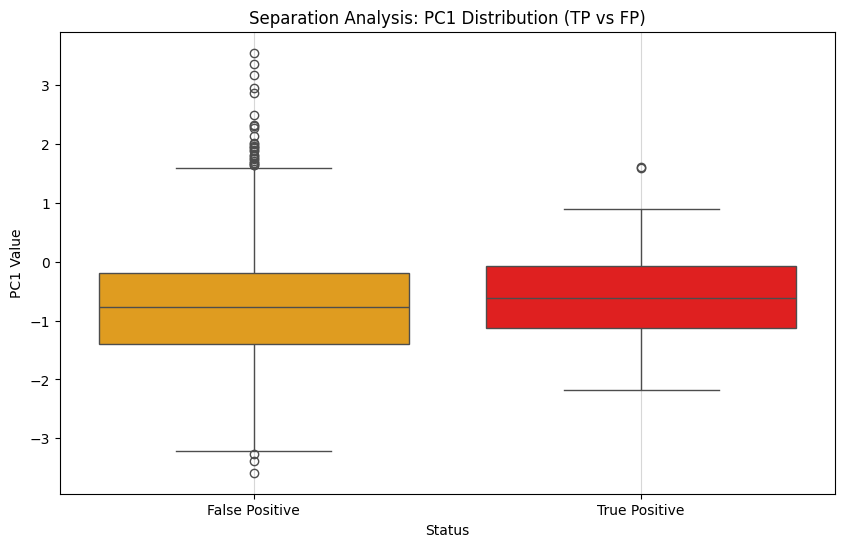

Statistics for PC1 (True Positive / Actual Defect):
count    36.000000
mean     -0.495127
std       0.885702
min      -2.171063
25%      -1.129562
50%      -0.611648
75%      -0.065025
max       1.604114
Name: PC1, dtype: float64

Statistics for PC1 (False Positive):
count    1414.000000
mean       -0.773933
std         1.070613
min        -3.583697
25%        -1.403566
50%        -0.760133
75%        -0.189696
max         3.551087
Name: PC1, dtype: float64


In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd

# taking the correct data set 
X_viz = datasets['raw_scaled'][1].copy()
pca = PCA(n_components=3)
X_pca_res = pca.fit_transform(X_viz)

df_plot = pd.DataFrame(X_pca_res, columns=['PC1', 'PC2', 'PC3'])
df_plot['True_Label'] = y_val.values
df_plot['Prediction'] = final_preds 

# set status 
def get_status(row):
    if row['True_Label'] == 1 and row['Prediction'] == 1:
        return 'True Positive'
    elif row['True_Label'] == 0 and row['Prediction'] == 1:
        return 'False Positive'
    else:
        return 'Other'

df_plot['Status'] = df_plot.apply(get_status, axis=1)

df_positive_predictions = df_plot[df_plot['Prediction'] == 1].copy()
plt.figure(figsize=(10, 6))

# Boxplot 
sns.boxplot(
    data=df_positive_predictions, 
    x='Status', 
    y='PC1',
    palette={'True Positive': 'red', 'False Positive': 'orange'}
)

plt.title('Separation Analysis: PC1 Distribution (TP vs FP)')
plt.ylabel('PC1 Value')
plt.grid(True, axis='x', alpha=0.5)
plt.show()

# Statistics output
print("Statistics for PC1 (True Positive / Actual Defect):")
print(df_positive_predictions[df_positive_predictions['Status'] == 'True Positive']['PC1'].describe())

print("\nStatistics for PC1 (False Positive):")
print(df_positive_predictions[df_positive_predictions['Status'] == 'False Positive']['PC1'].describe())

## 5.3 PCA-based false-alarm analysis

A validation-only post-processing rule removes positive predictions outside the PCA ranges occupied by true defects. The comparison below quantifies its effect on AUROC, Average Precision, recall, and false alarms.

In [84]:
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

print("--- PCA clipping with individual safety margin ---\n")

# Original probabilities & predictions 
final_proba_auto = final_proba.copy()
final_preds_auto = final_preds.copy() 
X_pca_data = X_pca_res 

# mask for TP
mask_tp = (y_val == 1) & (final_preds == 1)

# Loop across the dimension
dims = ["PC1", "PC2", "PC3"]

total_fp_removed = 0

for i, dim_name in enumerate(dims):

    if i == 0:  # PC1
        safety_margin = 0.3   
    else:       # PC2, PC3 
        safety_margin = 0.3  # 

    # calculate the clipping boundaries for the TP & set the buffer 
    tp_values = X_pca_data[mask_tp, i]
    tp_max = tp_values.max()
    tp_min = tp_values.min()
    upper_threshold = tp_max + (abs(tp_max) * safety_margin)
    lower_threshold = tp_min - (abs(tp_min) * safety_margin)
    

    values_all = X_pca_data[:, i]
    # mask for clipping
    mask_clip_upper = values_all > upper_threshold
    mask_clip_lower = values_all < lower_threshold
    mask_clip = mask_clip_upper | mask_clip_lower
    
    # statistics 
    current_fps = (y_val == 0) & (final_preds_auto == 1)
    fps_removed_here = (current_fps & mask_clip).sum()
    # apply clipping
    final_proba_auto[mask_clip] = 0.0
    final_preds_auto[mask_clip] = 0
    
    total_fp_removed += fps_removed_here
    
    print(f"[{dim_name}] Margin: {safety_margin:.0%} | Range: [{lower_threshold:.2f} ... {upper_threshold:.2f}]")
    if fps_removed_here > 0:
        print(f" Removed {fps_removed_here} False Positives.")
    else:
        print(f"  No FPs found outside safety zone.")

print(f"\n--- FINAL RESULT ---")
print(f"Total False Positives removed: {total_fp_removed}")

# Performance Check
new_roc_auc = roc_auc_score(y_val, final_proba_auto)
diff_roc = new_roc_auc - best_score

orig_pr_auc = average_precision_score(y_val, final_proba)
new_pr_auc = average_precision_score(y_val, final_proba_auto)
diff_pr = new_pr_auc - orig_pr_auc

print(f"\nMetric Comparison:")
print(f"ROC-AUC: {best_score:.4f} -> {new_roc_auc:.4f} ({diff_roc:+.4f})")
print(f"PR-AUC:  {orig_pr_auc:.4f} -> {new_pr_auc:.4f} ({diff_pr:+.4f})")

# Operational Metrics
cm_auto = confusion_matrix(y_val, final_preds_auto)
tn, fp, fn, tp = cm_auto.ravel()
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"\nOperational Performance:")
print(f"TP: {tp} (Recall: {recall:.1%})")
print(f"FP: {fp} (Precision: {precision:.1%})")

--- PCA clipping with individual safety margin ---

[PC1] Margin: 30% | Range: [-2.82 ... 2.09]
 Removed 48 False Positives.
[PC2] Margin: 30% | Range: [-2.93 ... 2.54]
 Removed 15 False Positives.
[PC3] Margin: 30% | Range: [-1.32 ... 2.74]
 Removed 33 False Positives.

--- FINAL RESULT ---
Total False Positives removed: 96

Metric Comparison:
ROC-AUC: 0.6991 -> 0.7176 (+0.0185)
PR-AUC:  0.0374 -> 0.0397 (+0.0022)

Operational Performance:
TP: 36 (Recall: 65.5%)
FP: 1318 (Precision: 2.7%)


## 5.4 Chronological test evaluation

In [85]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

# MLP inference (relevant for correct soft voting)
def get_mlp_preds_scaled(X_df, scaler_input, model_obj, scaler_output, device_obj):

    X_scaled = scaler_input.transform(X_df)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device_obj)
    
    model_obj.eval()
    with torch.no_grad():
        
        probs_raw = torch.sigmoid(model_obj(X_tensor)).cpu().numpy().flatten()
        probs_scaled = scaler_output.transform(probs_raw.reshape(-1, 1)).flatten()
        
    return probs_scaled

# calculate predictions
print("Calculating predictions for the chronological test split...")

# validation calculation
p_l2_val  = model_l2.predict_proba(datasets['reduced'][1])[:, 1]
p_en_val  = model_en.predict_proba(datasets['reduced'][1])[:, 1]
p_xgb_val = model_xgb.predict_proba(datasets['temporal'][1])[:, 1]
p_mlp_val = get_mlp_preds_scaled(datasets['temporal'][1], scaler, model, scaler_mlp, device)

# Inference
p_l2_test  = model_l2.predict_proba(datasets['reduced'][2])[:, 1]
p_en_test  = model_en.predict_proba(datasets['reduced'][2])[:, 1]
p_xgb_test = model_xgb.predict_proba(datasets['temporal'][2])[:, 1]
# MLP with scaling
p_mlp_test = get_mlp_preds_scaled(datasets['temporal'][2], scaler, model, scaler_mlp, device)

# Ensemble weights
w_mlp = 0.5
w_l2 = 0.05
w_en = 0
w_xgb = 0.45

THRESHOLD = 0.476

# validation Ensemble
final_proba_val  = (w_l2 * p_l2_val) + (w_en * p_en_val) + (w_xgb * p_xgb_val) + (w_mlp * p_mlp_val)
final_preds_val  = (final_proba_val >= THRESHOLD).astype(int)

# test Ensemble
final_proba_test = (w_l2 * p_l2_test) + (w_en * p_en_test) + (w_xgb * p_xgb_test) + (w_mlp * p_mlp_test)
final_preds_test = (final_proba_test >= THRESHOLD).astype(int)


# safe Zone for PCA clipping
mask_tp_val = (y_val == 1) & (final_preds_val == 1)
print(f"Validation Safe Zone based on {mask_tp_val.sum()} True Positives.")

test_proba_clipped = final_proba_test.copy()
test_preds_clipped = final_preds_test.copy()

# pca margin
n_comps = datasets['PCA'][1].shape[1] 
margins = [0.3, 0.3, 0.3, 0.1]       
clipped_count = 0

if mask_tp_val.sum() == 0:
    print("WARNING: No true positives available")
else:
    for i in range(n_comps):
        col_name = f"PCA_{i+1}"
        
        # validation border
        val_vals = datasets['PCA'][1].loc[mask_tp_val, col_name]
        if len(val_vals) == 0: continue
        
        upper = val_vals.max() + (abs(val_vals.max()) * margins[i])
        lower = val_vals.min() - (abs(val_vals.min()) * margins[i])
        
        # clipping
        test_vals = datasets['PCA'][2][col_name]
        mask_clip = (test_vals > upper) | (test_vals < lower)
        
        if mask_clip.sum() > 0:
            removed = (mask_clip & (test_preds_clipped == 1)).sum()
            clipped_count += removed
            
            test_proba_clipped[mask_clip] = 0.0
            test_preds_clipped[mask_clip] = 0

print(f"Removed {clipped_count} False Positives via Clipping.")

# Evaluation 
print(f"\n--- Final Test Results (Threshold {THRESHOLD}) ---")
print(f"ROC-AUC: {roc_auc_score(y_test, test_proba_clipped):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, test_proba_clipped):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, test_preds_clipped)}")
print(f"Total Predicted Positives: {test_preds_clipped.sum()} / {len(test_preds_clipped)} ({test_preds_clipped.mean():.2%})")

Calculating predictions for the chronological test split...
Validation Safe Zone based on 31 True Positives.
Removed 195 False Positives via Clipping.

--- Final Test Results (Threshold 0.476) ---
ROC-AUC: 0.6979
PR-AUC:  0.0155
Confusion Matrix:
[[3721 1415]
 [  13   29]]
Total Predicted Positives: 1444 / 5178 (27.89%)


/Users/I750252/Library/Python/3.12/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but StandardScaler was fitted without feature names

/Users/I750252/Library/Python/3.12/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but StandardScaler was fitted without feature names



## 5.5 Challenge test-set inference

In [86]:
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

test_df = pd.read_csv("data/testinputs.csv")

# Pipeline Features 
df_test_sorted = extract_and_sort_time(test_df)
df_test_domain = add_domain_features(df_test_sorted)
df_test_full = add_advanced_temporal_features(df_test_domain)
df_test_full = df_test_full.fillna(0) 

# alignment with training
cols_reduced = datasets['reduced'][0].columns.tolist()
cols_temporal = datasets['temporal'][0].columns.tolist()
cols_baseline = datasets['baseline'][0].columns.tolist()

# match columns 
X_ch_reduced = df_test_full.reindex(columns=cols_reduced, fill_value=0)
X_ch_temporal = df_test_full.reindex(columns=cols_temporal, fill_value=0)
X_ch_baseline_aligned = df_test_full.reindex(columns=cols_baseline, fill_value=0)

scaler_reduced = StandardScaler()
scaler_reduced.fit(train_df[cols_reduced].fillna(0)) 

X_ch_reduced_scaled = pd.DataFrame(
    scaler_reduced.transform(X_ch_reduced),
    columns=cols_reduced, index=df_test_full.index
)

# Scaler 
scaler_baseline = StandardScaler().fit(datasets['baseline'][0])
X_ch_raw_scaled = pd.DataFrame(
    scaler_baseline.transform(X_ch_baseline_aligned), 
    columns=cols_baseline, index=df_test_full.index
)

# Scaler 
scaler_temporal = StandardScaler().fit(datasets['temporal'][0])
X_ch_temporal_scaled = scaler_temporal.transform(X_ch_temporal)

# PCA 
n_comps = pca.n_components_
pca_cols = [f"PCA_{i+1}" for i in range(n_comps)]

X_ch_pca = pd.DataFrame(
    pca.transform(X_ch_raw_scaled), 
    columns=pca_cols, index=df_test_full.index
)

print(f"--- 4. Inference (Ensemble) ---")

# predictions
probs_l2 = model_l2.predict_proba(X_ch_reduced_scaled)[:, 1]
probs_en = model_en.predict_proba(X_ch_reduced_scaled)[:, 1]
probs_xgb = model_xgb.predict_proba(X_ch_temporal)[:, 1] 

# MLP
X_ch_tensor = torch.tensor(X_ch_temporal_scaled, dtype=torch.float32).to(device)
model.eval()
with torch.no_grad():
    probs_mlp_raw = torch.sigmoid(model(X_ch_tensor)).cpu().numpy().flatten()
    probs_mlp = scaler_mlp.transform(probs_mlp_raw.reshape(-1, 1)).flatten()

# Ensemble weights
w_mlp = 0.5
w_l2 = 0.05
w_en = 0
w_xgb = 0.45

THRESHOLD = 0.476

final_proba_ch = (w_l2 * probs_l2) + (w_en * probs_en) + (w_xgb * probs_xgb) + (w_mlp * probs_mlp)

# Threshold (Youden Optimum)
final_preds_ch = (final_proba_ch >= THRESHOLD).astype(int)

# PCA clipping
p_l2_val = model_l2.predict_proba(datasets['reduced'][1])[:, 1]
p_en_val = model_en.predict_proba(datasets['reduced'][1])[:, 1]
p_xgb_val = model_xgb.predict_proba(datasets['temporal'][1])[:, 1]

# MLP Validation (Input + Output Scaling)
X_val_temporal_scaled = scaler_temporal.transform(datasets['temporal'][1])
X_val_tensor = torch.tensor(X_val_temporal_scaled, dtype=torch.float32).to(device)
with torch.no_grad():
    p_mlp_val_raw = torch.sigmoid(model(X_val_tensor)).cpu().numpy().flatten()
    p_mlp_val = scaler_mlp.transform(p_mlp_val_raw.reshape(-1, 1)).flatten()

# Ensemble Val
val_proba = (w_l2 * p_l2_val) + (w_en * p_en_val) + (w_xgb * p_xgb_val) + (w_mlp * p_mlp_val)
val_preds = (val_proba >= THRESHOLD).astype(int)
mask_tp_val = (y_val == 1) & (val_preds == 1)

clipped_final_preds = final_preds_ch.copy()
margins = [0.3, 0.3, 0.3, 0.2] 
clipped_count = 0

if mask_tp_val.sum() == 0:
    print("WARNING: No validation true positives. PCA clipping is skipped.")
else:
    for i in range(n_comps):
        col_name = f"PCA_{i+1}"
        
        # borders 
        val_vals = datasets['PCA'][1].loc[mask_tp_val, col_name]
        upper = val_vals.max() + (abs(val_vals.max()) * margins[i])
        lower = val_vals.min() - (abs(val_vals.min()) * margins[i])
        
        # clipping
        test_vals = X_ch_pca[col_name]
        mask_out = (test_vals > upper) | (test_vals < lower)
        
        if mask_out.sum() > 0:
            removed = (mask_out & (clipped_final_preds == 1)).sum()
            clipped_count += removed
            clipped_final_preds[mask_out] = 0

print(f"\n--- Final Statistics ---")
total = len(df_test_full)
pos_raw = final_preds_ch.sum()
pos_final = clipped_final_preds.sum()

print(f"Total Samples:       {total}")
print(f"Positives (Raw):     {pos_raw} ({pos_raw/total:.2%})")
print(f"Removed via Clipping: {clipped_count}")
print(f"Positives (Final):   {pos_final} ({pos_final/total:.2%})")

# Export
submission_df = pd.DataFrame({
    'PROC_TRACEINFO': df_test_full['PROC_TRACEINFO'],
    'prediction': clipped_final_preds
})
filename = "submission_final_fixed.csv"
submission_df.to_csv(filename, index=False)
print(f"Saved '{filename}'.")

--- 4. Inferenz (Ensemble) ---

--- Final Statistics ---
Total Samples:       8001
Positives (Raw):     2480 (31.00%)
Removed via Clipping: 692
Positives (Final):   1788 (22.35%)
Datei 'submission_final_fixed.csv' gespeichert.


# 6. Robustness and diagnostics

The final analyses compare validation windows, inspect temporal defect rates, and visualize rolling z-score fingerprints for defective products.

In [87]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# --- 1. DATA PREPARATION ---

# Helper to extract a validation window
def get_split_data(df, target_col, train_ratio, val_ratio):
    df_sorted = df.sort_values("prod_index")
    n = len(df_sorted)
    idx_train = int(n * train_ratio)
    idx_val = int(n * (train_ratio + val_ratio))
    val = df_sorted.iloc[idx_train:idx_val].copy()
    range_info = f"Idx: {idx_train}-{idx_val}"
    return val, range_info

# Features
target_col = "Binar OP130_Resultat_Global_v"
eng_keywords = ["_Z50", "_diff", "_ratio", "_missing", "_lag", "_delta", "power", "energy", "stiffness", "profile", "inv", "_mean", "_std", "_min", "_max", "_median", "_var", "_rolling"]
drop_cols = ["PROC_TRACEINFO", "product_ref", "prod_date_str", "prod_timestamp", "prod_index", "index_diff", target_col]
all_cols = [c for c in df_full_features.columns if c not in drop_cols]
raw_cols = [c for c in all_cols if not any(k in c.lower() for k in eng_keywords) and c not in ["prod_year", "prod_month", "prod_day"]]

# Extract validation windows (10% und 15% scenario)
val_10, range_10 = get_split_data(df_full_features, target_col, 0.8, 0.1)
val_15, range_15 = get_split_data(df_full_features, target_col, 0.7, 0.15)

# Fit PCA on the first 70%
train_basis = df_full_features.sort_values("prod_index").iloc[:int(len(df_full_features)*0.7)]
imputer = SimpleImputer(strategy='median')
pca = PCA(n_components=3, random_state=42)
pca.fit(imputer.fit_transform(train_basis[raw_cols]))

# Transform validation windows
X_10 = pca.transform(imputer.transform(val_10[raw_cols]))
X_15 = pca.transform(imputer.transform(val_15[raw_cols]))

df_10 = pd.DataFrame(X_10, columns=['PC1', 'PC2', 'PC3']); df_10['target'] = val_10[target_col].values
df_15 = pd.DataFrame(X_15, columns=['PC1', 'PC2', 'PC3']); df_15['target'] = val_15[target_col].values

# Separate defective and conforming products
ko_10 = df_10[df_10.target == 1]
ko_15 = df_15[df_15.target == 1]
# Background of conforming products
ok_background = pd.concat([df_10[df_10.target==0], df_15[df_15.target==0]]).sample(frac=0.5) # Sample 50% for rendering performance

# --- 2. INTERACTIVE PLOTLY CHART ---

fig = go.Figure()

# A. Conforming-product background
fig.add_trace(go.Scatter3d(
    x=ok_background['PC1'], y=ok_background['PC2'], z=ok_background['PC3'],
    mode='markers',
    marker=dict(size=2, color='gray', opacity=0.1),
    name='OK Samples (Background)'
))

# B. Defects from the 15% validation window
# Use open circles so overlapping observations remain visible
fig.add_trace(go.Scatter3d(
    x=ko_15['PC1'], y=ko_15['PC2'], z=ko_15['PC3'],
    mode='markers',
    marker=dict(size=6, color='green', symbol='circle', opacity=0.8, line=dict(width=2, color='green')),
    name=f'15% Val ({len(ko_15)} KOs)'
))

# C. Defects from the 10% validation window
fig.add_trace(go.Scatter3d(
    x=ko_10['PC1'], y=ko_10['PC2'], z=ko_10['PC3'],
    mode='markers',
    marker=dict(size=4, color='red', symbol='diamond'),
    name=f'10% Val ({len(ko_10)} KOs)'
))

# Layout
fig.update_layout(
    title="Interactive PCA: defects across 10% and 15% validation windows",
    width=1000,
    height=700,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

In [88]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# --- 1. SETUP AND FEATURE SELECTION ---

# Define calendar features
time_cols = ["prod_year", "prod_month", "prod_day"]

# Helper to extract validation windows
def get_split_data(df, target_col, train_ratio, val_ratio):
    df_sorted = df.sort_values("prod_index")
    n = len(df_sorted)
    idx_train = int(n * train_ratio)
    idx_val = int(n * (train_ratio + val_ratio))
    val = df_sorted.iloc[idx_train:idx_val].copy()
    range_info = f"Idx: {idx_train}-{idx_val}"
    return val, range_info

target_col = "Binar OP130_Resultat_Global_v"

# Validate required columns
missing_cols = [c for c in time_cols if c not in df_full_features.columns]
if missing_cols:
    raise ValueError(f"Missing time columns: {missing_cols}. Run 'extract_and_sort_time' first.")

# Extract validation windows
val_10, range_10 = get_split_data(df_full_features, target_col, 0.8, 0.1)
val_15, range_15 = get_split_data(df_full_features, target_col, 0.7, 0.15)

# --- 2. PCA ON TEMPORAL FEATURES ---

# Fit PCA on the first 70% so both validation windows share one space
train_basis = df_full_features.sort_values("prod_index").iloc[:int(len(df_full_features)*0.7)]

# Imputation and PCA
imputer = SimpleImputer(strategy='median')
# Three components are used because the temporal view contains year, month, and day. 
# 
pca_time = PCA(n_components=3, random_state=42)

# Fit on the training period
X_basis_time = imputer.fit_transform(train_basis[time_cols])
pca_time.fit(X_basis_time)

# Transform validation windows der Validierungs-Sets
X_10 = pca_time.transform(imputer.transform(val_10[time_cols]))
X_15 = pca_time.transform(imputer.transform(val_15[time_cols]))

# Create analysis frames
df_10 = pd.DataFrame(X_10, columns=['PC1', 'PC2', 'PC3']); df_10['target'] = val_10[target_col].values
df_15 = pd.DataFrame(X_15, columns=['PC1', 'PC2', 'PC3']); df_15['target'] = val_15[target_col].values

# Separate defects and background observations
ko_10 = df_10[df_10.target == 1]
ko_15 = df_15[df_15.target == 1]
ok_background = pd.concat([df_10[df_10.target==0], df_15[df_15.target==0]])

# Sample the background when needed for interactive rendering
if len(ok_background) > 5000:
    ok_background = ok_background.sample(n=5000, random_state=42)

# --- 3. BUILD INTERACTIVE PLOT ---

fig = go.Figure()

# A. Temporal structure of conforming products
fig.add_trace(go.Scatter3d(
    x=ok_background['PC1'], y=ok_background['PC2'], z=ok_background['PC3'],
    mode='markers',
    marker=dict(size=3, color='gray', opacity=0.15),
    name='OK Timeline (Background)'
))

# B. Defects in the 15% validation window
fig.add_trace(go.Scatter3d(
    x=ko_15['PC1'], y=ko_15['PC2'], z=ko_15['PC3'],
    mode='markers',
    marker=dict(size=7, color='green', symbol='circle', opacity=0.8, line=dict(width=2, color='darkgreen')),
    name=f'15% Val ({len(ko_15)} KOs)'
))

# C. Defects in the 10% validation window
fig.add_trace(go.Scatter3d(
    x=ko_10['PC1'], y=ko_10['PC2'], z=ko_10['PC3'],
    mode='markers',
    marker=dict(size=5, color='red', symbol='diamond', opacity=1.0),
    name=f'10% Val ({len(ko_10)} KOs)'
))

# Layout
fig.update_layout(
    title=f"Interactive PCA: temporal dataset (Year/Month/Day)<br>Variance Explained: {pca_time.explained_variance_ratio_}",
    width=1000,
    height=700,
    scene=dict(
        xaxis_title='PC1 (primary time axis)',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

print("Generating visualization...")
print(f"Explained Variance Ratio: {pca_time.explained_variance_ratio_}")
fig.show()

Visualisierung wird generiert...
Explained Variance Ratio: [0.9777107 0.0222893 0.       ]


Global Average Defect Rate: 0.884%


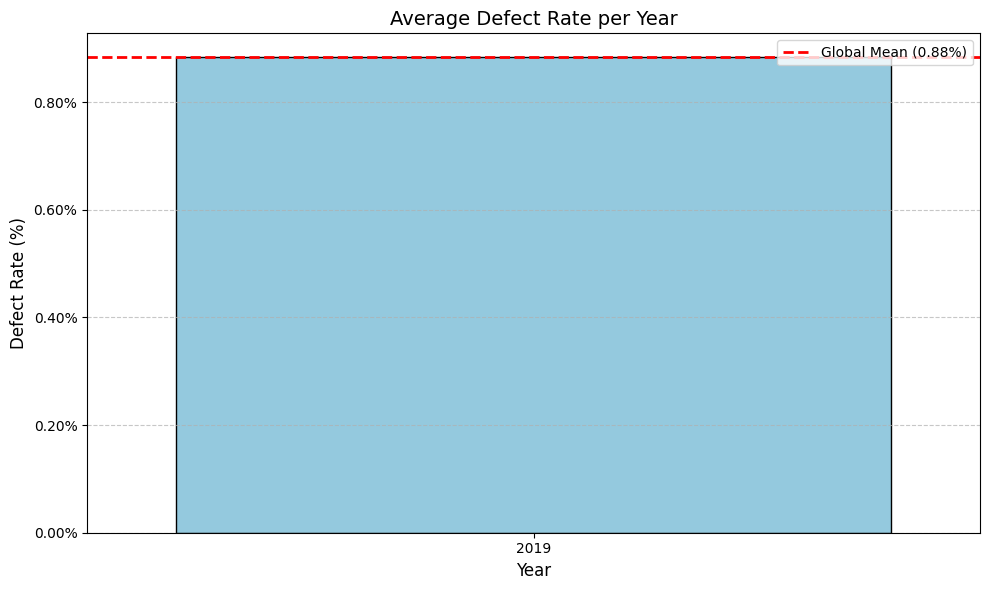

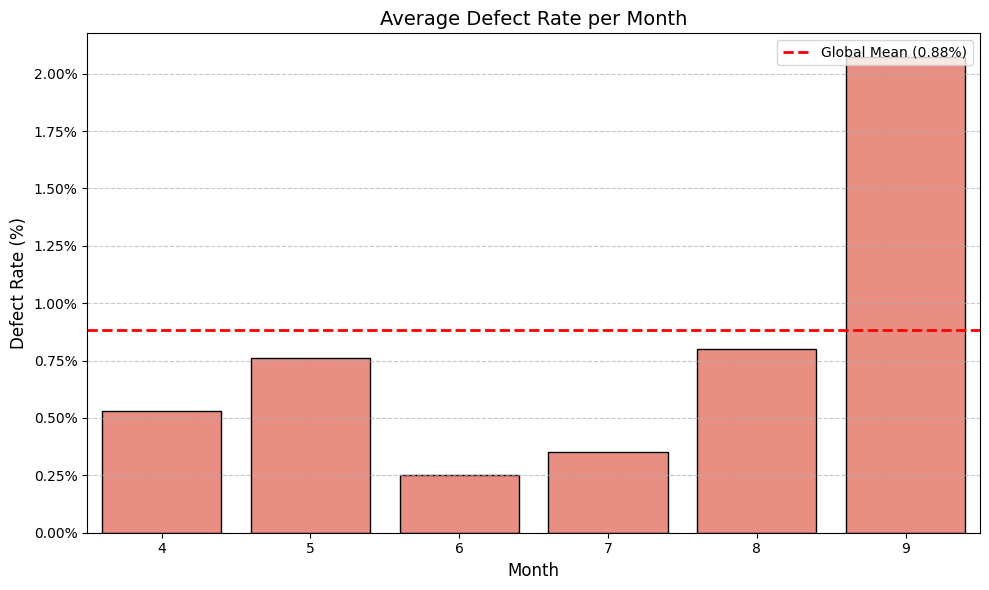

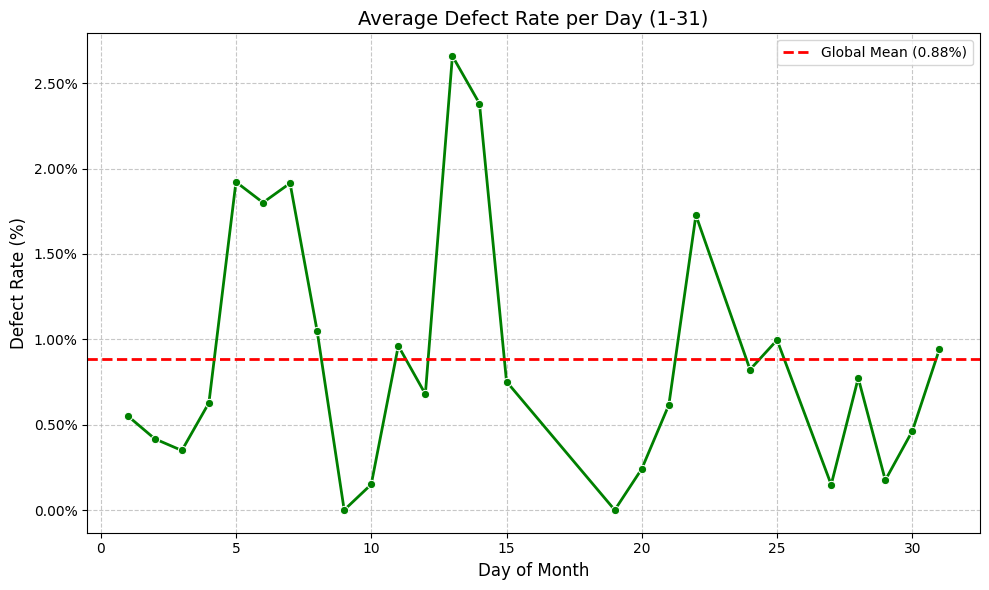

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# Name your target column
target_viz = target_col 

# Create a copy and convert target to Percentage
df_plot = df_sorted.copy()
df_plot['defect_pct'] = df_plot[target_viz] * 100

# Calculate Global Mean in Percent
global_mean_pct = df_plot['defect_pct'].mean()
print(f"Global Average Defect Rate: {global_mean_pct:.3f}%")

# ==========================================
# 1. IMAGE: YEAR vs. DEFECT RATE
# ==========================================
plt.figure(figsize=(10, 6))
yearly_rate = df_plot.groupby('prod_year')['defect_pct'].mean().reset_index()

ax = sns.barplot(x='prod_year', y='defect_pct', data=yearly_rate, color='skyblue', edgecolor='black')

# Formatting
plt.title('Average Defect Rate per Year', fontsize=14)
plt.ylabel('Defect Rate (%)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.axhline(global_mean_pct, color='red', linestyle='--', linewidth=2, label=f'Global Mean ({global_mean_pct:.2f}%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


# ==========================================
# 2. IMAGE: MONTH vs. DEFECT RATE
# ==========================================
plt.figure(figsize=(10, 6))
monthly_rate = df_plot.groupby('prod_month')['defect_pct'].mean().reset_index()

ax = sns.barplot(x='prod_month', y='defect_pct', data=monthly_rate, color='salmon', edgecolor='black')

# Formatting
plt.title('Average Defect Rate per Month', fontsize=14)
plt.ylabel('Defect Rate (%)', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.axhline(global_mean_pct, color='red', linestyle='--', linewidth=2, label=f'Global Mean ({global_mean_pct:.2f}%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


# ==========================================
# 3. IMAGE: DAY vs. DEFECT RATE
# ==========================================
plt.figure(figsize=(10, 6))
daily_rate = df_plot.groupby('prod_day')['defect_pct'].mean().reset_index()

ax = sns.lineplot(x='prod_day', y='defect_pct', data=daily_rate, marker='o', color='green', linewidth=2)

# Formatting
plt.title('Average Defect Rate per Day (1-31)', fontsize=14)
plt.ylabel('Defect Rate (%)', fontsize=12)
plt.xlabel('Day of Month', fontsize=12)
plt.axhline(global_mean_pct, color='red', linestyle='--', linewidth=2, label=f'Global Mean ({global_mean_pct:.2f}%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Calculating rolling z-scores (Window=50)...
Plotting Fingerprint for 20 defective samples...


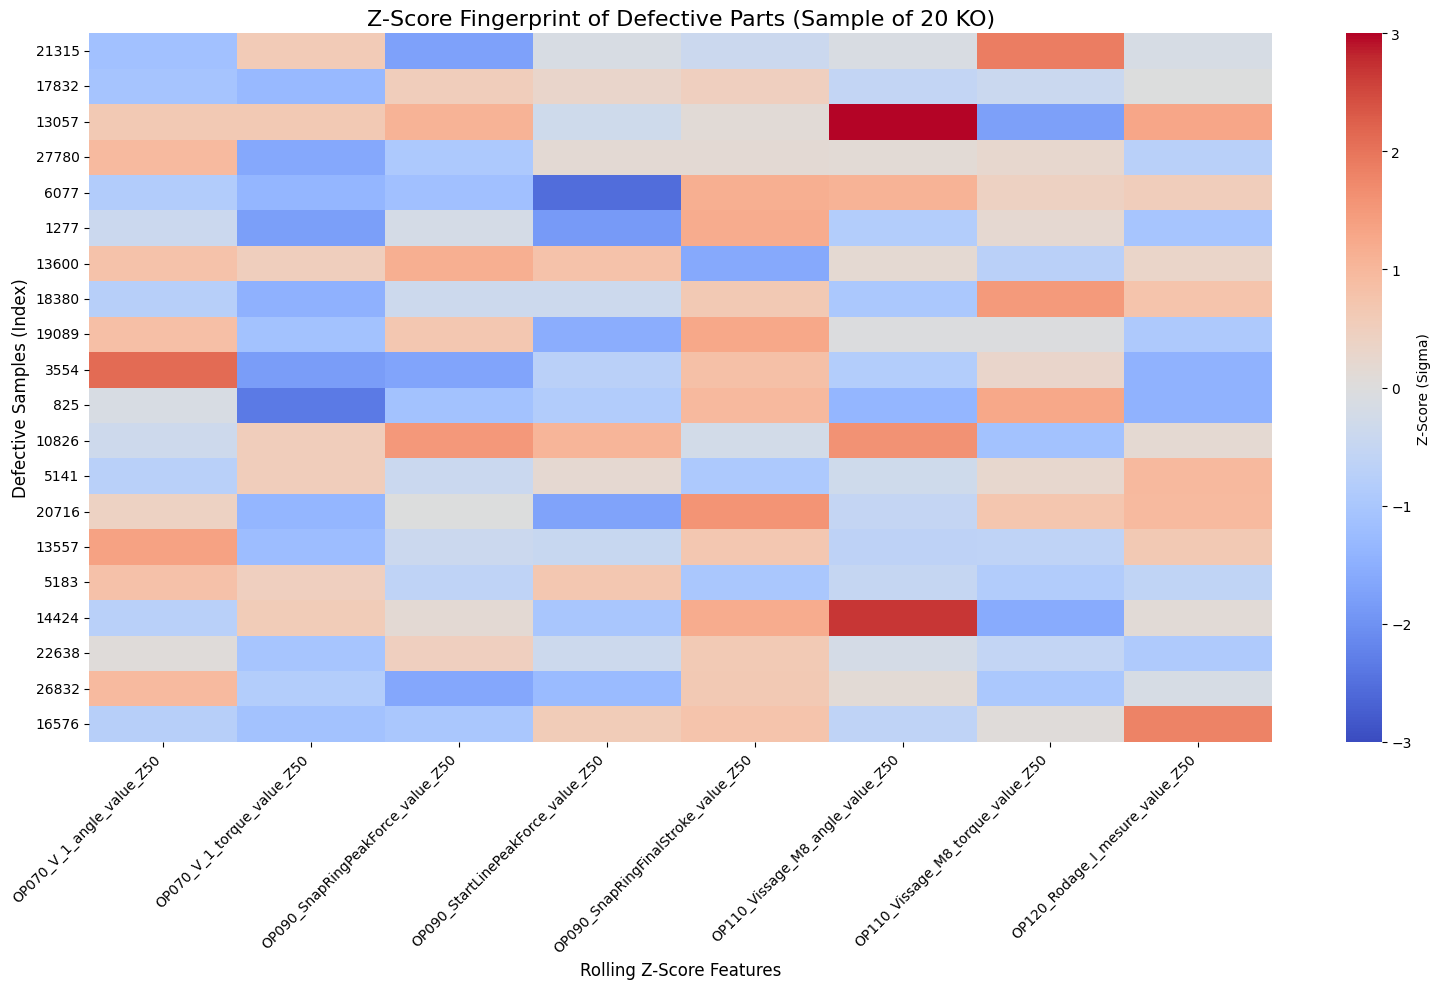

In [90]:
# ==========================================
# 4. Z-SCORE FINGERPRINT (Anomaly Detection)
# ==========================================

# 1. Definiere die Raw-Features, die wir analysieren wollen (basierend auf deinem Bild)
# Stelle sicher, dass diese Spaltennamen exakt so in deinem df_sorted existieren.
features_of_interest = [
    "OP070_V_1_angle_value", 
    "OP070_V_1_torque_value",
    "OP090_SnapRingPeakForce_value", 
    "OP090_StartLinePeakForce_value",
    "OP090_SnapRingFinalStroke_value",
    "OP110_Vissage_M8_angle_value", 
    "OP110_Vissage_M8_torque_value",
    "OP120_Rodage_I_mesure_value"
]

# 2. Calculating rolling z-scores (Window = 50)
# Work on a copy to preserve the source frame
df_fingerprint = df_sorted.copy()
z_score_cols = []

print("Calculating rolling z-scores (Window=50)...")

for col in features_of_interest:
    if col in df_fingerprint.columns:
        # Rolling Mean & Std berechnen
        roll_mean = df_fingerprint[col].rolling(window=50).mean()
        roll_std = df_fingerprint[col].rolling(window=50).std()
        
        # Z-score formula: (Value - Mean) / Std
        # Fill the initial rolling-window gaps with zero for visualization
        z_col_name = f"{col}_Z50"
        df_fingerprint[z_col_name] = ((df_fingerprint[col] - roll_mean) / roll_std).fillna(0)
        z_score_cols.append(z_col_name)

# 3. Filtere nur die defekten Teile (KO Samples)
# target_viz kommt aus dem vorherigen Code-Block
df_ko = df_fingerprint[df_fingerprint[target_viz] == 1]

# 4. Ziehe eine Zufallsstichprobe von 20 Teilen (falls genug vorhanden sind)
if len(df_ko) > 20:
    df_ko_sample = df_ko.sample(n=20, random_state=42)
else:
    df_ko_sample = df_ko # Nimm alle, wenn weniger als 20

print(f"Plotting Fingerprint for {len(df_ko_sample)} defective samples...")

# 5. Erstelle die Heatmap
plt.figure(figsize=(16, 10))

# Wir nutzen vmin=-3 und vmax=3, da Z-Scores selten größer als 3 Sigma sind (Ausreißer)
sns.heatmap(
    df_ko_sample[z_score_cols], 
    cmap='coolwarm',    # Blau (tief) -> Weiß (normal) -> Rot (hoch)
    center=0,           # 0 ist der Durchschnitt
    vmin=-3, vmax=3,    # Skala begrenzen für besseren Kontrast
    annot=False,        # Zahlen im Kästchen weglassen (zu unübersichtlich)
    cbar_kws={'label': 'Z-Score (Sigma)'}
)

plt.title(f'Z-Score Fingerprint of Defective Parts (Sample of {len(df_ko_sample)} KO)', fontsize=16)
plt.xlabel('Rolling Z-Score Features', fontsize=12)
plt.ylabel('Defective Samples (Index)', fontsize=12)

# X-Achsen Labels rotieren für Lesbarkeit
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()